In [44]:
import os
import sys

EXAMPLE_DIR = os.getcwd()
if os.path.basename(EXAMPLE_DIR) != "4DCartPoler":
    EXAMPLE_DIR = os.path.join(EXAMPLE_DIR, "examples", "4DCartPoler")
project_root = os.path.abspath(os.path.join(EXAMPLE_DIR, "../.."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if EXAMPLE_DIR not in sys.path:
    sys.path.insert(0, EXAMPLE_DIR)

# Make sure Ray subprocesses also see this
os.environ["PYTHONPATH"] = project_root + ":" + os.environ.get("PYTHONPATH", "")


In [45]:
import numpy as np
import random
import functools
import yaml

from deap import gp
from flex.gp.regressor import GPSymbolicRegressor
import warnings
import ray
from flex.gp import util
from flex.gp.primitives import add_primitives_to_pset_from_dict

from sympy import symbols, lambdify, sin, sqrt, pprint, latex, cos, tanh, diff, simplify
from IPython.display import display, Math

from SystemDynamicsSR import fSR, xSR, GSR, QSR, RSR

from src.Fitness import fitness, assign_attributes
from src.PredictScoreFuncs import predict, score
import src.Functions
from src.SymFunctions import read_expressionCoef, substitute_paramsCoef, DeapSimplifier
from src.VVdot_Calculations import compute_v_and_v_dot
from src.SymVVdot_Calculations import compute_v_and_v_dotSR

import matplotlib.pyplot as plt

import time

import pygmo as pg
import re

from sklearn.metrics import r2_score


In [46]:
# Define the numerical grid (Domain)
GRID_POINTS = 21
x_Domain = 0.25
x1_vals = np.linspace(-x_Domain, x_Domain, GRID_POINTS)
x2_vals = np.linspace(-x_Domain, x_Domain, GRID_POINTS)
x3_vals = np.linspace(-x_Domain, x_Domain, GRID_POINTS)
x4_vals = np.linspace(-x_Domain, x_Domain, GRID_POINTS)

X1, X2, X3, X4 = np.meshgrid(x1_vals, x2_vals, x3_vals, x4_vals, indexing="ij")

train_data = src.Functions.Dataset("true_data", [x1_vals, x2_vals, x3_vals, x4_vals], None)
train_data.X1 = X1
train_data.X2 = X2
train_data.X3 = X3
train_data.X4 = X4
train_data.grid_shape = X1.shape
train_data.mesh = [X1, X2, X3, X4]


In [47]:
# Prefer the Prime run output; fall back to the original best_expression.txt
best_file = os.path.join(EXAMPLE_DIR, "best_expression015.txt")
# if not os.path.exists(best_file):
#     best_file = os.path.join(EXAMPLE_DIR, "best_expression.txt")
#     print("best_expressionPrime.txt not found - falling back to:", best_file)
expression, fitness, parameters = read_expressionCoef(best_file)

# Reference quadratic:

# expression = "1.82179*x1^2 + 2.31883*x1*x2 - 12.9323*x1*x3 - 4.83766*x1*x4 + 1.64992*x2^2 - 18.7222*x2*x3 - 6.96603*x2*x4 + 56.1947*x3^2 + 40.8108*x3*x4 + 7.61264*x4^2"

# expression = "1.965366*x1**2 + 2.862562*x1*x2 - 13.368898*x1*x3 - 5.925124*x1*x4 + 2.143945*x2**2 - 20.349648*x2*x3 - 8.970854*x2*x4 + 50.818966*x3**2 + 43.681856*x3*x4 + 9.639298*x4**2"

# expression = "x1**2 + x2**2 + x3**2 + x4**2 + x1*x2"

expression = substitute_paramsCoef(expression, parameters)
simplified_expr = DeapSimplifier(expression, should_print=True)
display(Math(latex(simplified_expr)))


Original Expression: exp(sub(sub(x4, -3.87268252), sub(sub(add(x1, x4), aq(add(-7.87763601, x1), add(mul(sub(add(x3, x3), sub(sub(add(x3, x2), add(add(add(sub(add(x3, x3), sub(x1, x4)), x3), add(sub(add(x3, x3), sub(x2, x4)), x3)), x2)), x4)), add(x1, sub(sub(sub(add(x3, x2), add(add(x3, add(sub(add(x3, x3), sub(x2, x4)), x3)), x2)), x4), add(-7.4039538, x3)))), sub(x4, x2)))), sub(x2, x2))))
Simplified Expression: 48.0711651393052*exp(-x1 + (x1 - 7.87763601)/((-x2 + x4 + (-x1 - x2 + 7*x3 + 3*x4)*(x1 + x2 - 4*x3 - 2*x4 + 7.4039538))**2 + 1)**0.5)


<IPython.core.display.Math object>

In [48]:
# check with formal verification
# penalize b=0 a=0
# introduce gamma to the a(x) condition


In [49]:
print(fitness)

43.2682


In [50]:
import json
import os

history_file = os.path.join(EXAMPLE_DIR, "78857_best_per_generation.jsonl")
history_file = os.path.join(EXAMPLE_DIR, "79402_best_per_generation.jsonl")
# history_file = os.path.join(EXAMPLE_DIR, "83214_best_per_generation.jsonl")
# history_file = os.path.join(EXAMPLE_DIR, "83224_best_per_generation.jsonl")
# history_file = os.path.join(EXAMPLE_DIR, "83230_best_per_generation.jsonl")
history_file = os.path.join(EXAMPLE_DIR, "96051_best_per_generation.jsonl")
# history_file = os.path.join(EXAMPLE_DIR, "99778_best_per_generation.jsonl")
# history_file = os.path.join(EXAMPLE_DIR, "99830_best_per_generation.jsonl")
# history_file = os.path.join(EXAMPLE_DIR, "100172_best_per_generation.jsonl")
# history_file = os.path.join(EXAMPLE_DIR, "122232_best_per_generation.jsonl")
# history_file = os.path.join(EXAMPLE_DIR, "122299_best_per_generation.jsonl")
history_file = os.path.join(EXAMPLE_DIR, "122300_best_per_generation.jsonl")
history_file = os.path.join(EXAMPLE_DIR, "122304_best_per_generation.jsonl")
# history_file = os.path.join(EXAMPLE_DIR, "122339_best_per_generation.jsonl")
# history_file = os.path.join(EXAMPLE_DIR, "122340_best_per_generation.jsonl")
history_file = os.path.join(EXAMPLE_DIR, "122350_best_per_generation.jsonl")
# history_file = os.path.join(EXAMPLE_DIR, "122354_best_per_generation.jsonl")


expressions = []

with open(history_file, "r", encoding="utf-8") as file:
    for line in file:
        line = line.strip()
        if not line:
            continue

        rec = json.loads(line)

        expression = rec["expression"]
        parameters = rec.get("constants", [])

        expression = substitute_paramsCoef(expression, parameters)
        expression = DeapSimplifier(expression, should_print=False)

        expressions.append(expression)

print(f"Loaded {len(expressions)} ready expressions.")

Loaded 113 ready expressions.


In [51]:
k = len(expressions)
simplified_expr = expressions[k - 1]
print(simplified_expr)
display(Math(latex(simplified_expr)))

-x3*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**0.5 + 0.79474337497756261*(-0.3143580049734382*x3*(x2 + 7.372296470101777*exp(x4) + sin(x1))*sin(x2) - 7.820626741626682/((x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))**2 + 1)**0.5)/(x1**2 + 1)**0.5


<IPython.core.display.Math object>

In [52]:
import pandas as pd
from IPython.display import display, Math
from sympy import latex

x1, x2, x3, x4 = symbols("x1 x2 x3 x4")

rows = []

for k, expr in enumerate(expressions, start=1):
    expr_x3x4_0 = DeapSimplifier(
        str(expr.subs({x3: 0, x4: 0})),
        should_print=False,
    )

    rows.append({
        "generation": k,
        "expression_x3_x4_0": expr_x3x4_0,
        "latex": latex(expr_x3x4_0),
    })

expressions_x3x4_0 = pd.DataFrame(rows)

display(expressions_x3x4_0[["generation", "expression_x3_x4_0"]])

# import pandas as pd

# with pd.option_context(
#     "display.max_rows", None,
#     "display.max_columns", None,
#     "display.max_colwidth", None,
#     "display.width", None,
# ):
#     display(expressions_x3x4_0[["generation", "expression_x3_x4_0"]])

,generation,expression_x3_x4_0
0,1,1.0*x1**2 + 1.0*x1*x2 + 1.0*x2**2
1,2,sin(x1 + x2 - 1.521362944961581)
2,3,1.0*x1**2 - 0.509429455021376*x1*x2 + 1.0*x2**2
3,4,x1**2
4,5,sin(x1 + x2 - 20.42784134565765*exp(x1))
...,...,...
108,109,-0.92078941137461997/((x1**2 + 1)**0.5*((2*x1 ...
109,110,-7.959084570095175/((x1**2 + 1)**0.5*((2*x1 + ...
110,111,-3.907465994229343/((x1**2 + 1)**0.5*((3*x1 + ...
111,112,-6.2153912910801678/((x1**2 + 1)**0.5*((x1 + 5...


In [53]:
# print(expressions)

In [54]:
# print(parameters)

In [55]:
TRQlim = None # or 0.735
TrnOFFb=False # or True

In [56]:
# Define symbolic variables
x1, x2, x3, x4 = symbols('x1 x2 x3 x4')
V_func = lambdify((x1, x2, x3, x4), simplified_expr, modules='numpy')
V_vals = V_func(X1, X2, X3, X4)
V_vals = np.asarray(V_vals)
if V_vals.ndim == 0:
    V_vals = np.full(X1.shape, V_vals)

x_vals = [x1_vals, x2_vals, x3_vals, x4_vals]

from SystemDynamics import f, G, Q, R


In [57]:
_, V_grad_mag, V_dot_vals, lambda_vals, u_vals, u_mag, a_vals, [b_nvals, b0, b1], xn = compute_v_and_v_dot(
    V_vals,
    x_vals,
    train_data,
    [1.0, 1.0, 1.0, 1.0],
    f,
    G,
    Q,
    R,
    TRQlim,
    u_func=None,
    TrnOFFb=True,
)


In [58]:
V_grad_mag2 = np.abs(np.mean(V_grad_mag) - 0)
V_grad_mag2

np.float64(17.315813960189274)

In [59]:
# V_violations = np.count_nonzero(V_vals <= 0)
# print("V_violations:", V_violations)

# # Retired (Bug 2): Vdot under the min-norm u is -sqrt(a^2 + xQx*b'R^-1 b) <= 0
# # for ANY V wherever b != 0, so this count can never fire. The corrected,
# # bounded-control version is V_dot_violations in the breakdown cell below.
# # Vdot_violations = np.count_nonzero(V_dot_vals >= -0.0012 * xn)
# # print(Vdot_violations)

# # Retired (Bug 4): b_nvals = b'R^-1 b = 1e4*b^2, so sqrt(b_nvals) < 1e-6 means
# # |b| < 1e-8 -- 100x stricter than the intended ||b|| < 1e-6, and that band
# # contains no grid points anyway. Subsumed by the bounded-control margin below.
# # a_violations = np.count_nonzero((a_vals > 0) & (b_nvals**0.5 < 0.000001))
# # print(a_violations)

# # Bounded-control CLF margin on the grid:
# #   a(x) - U_MAX*|b(x)| + CLF_ALPHA*V(x) <= 0  on  {V < c*} \ origin ball
# # (the real CLF condition, including the b = 0 manifold)
# import Evaluate

# V0_prime = float(np.asarray(V_func(0.0, 0.0, 0.0, 0.0)))
# margin_penalty, c_star, margin_report = Evaluate._grid_clf_margin(
#     V_vals, V0_prime, x_vals, train_data.mesh, train_data
# )
# print("prime clf_margin_count:", margin_report["clf_margin_count"])
# print("prime clf_margin_soft:", margin_report["clf_margin_soft"])
# print("prime clf_margin_penalty:", margin_report["clf_margin_penalty"])
# print("prime c_star (largest sublevel set inside the box):", c_star)


In [60]:
print("V_vals.min()):", V_vals.min())
print("V_vals.max()):", V_vals.max())
print("V_dot_vals.max()):", V_dot_vals.max())
print("V_dot_vals.min()):", V_dot_vals.min())
print("a_vals.max()):", a_vals.max())
print("a_vals.min()):", a_vals.min())

V_vals.min()): -6.215752411234909
V_vals.max()): -0.2796772294706254
V_dot_vals.max()): 0.0
V_dot_vals.min()): -700.8984509439633
a_vals.max()): 38.9974417495439
a_vals.min()): -39.988256457571204


In [61]:
ind2MSE = simplified_expr  #expression
consts = parameters

import Evaluate

# Base verifier knobs live in Evaluate (EvaluatePrime wraps and reuses it).
# Evaluate.NUMERICAL_VERIFIER = "de"
TRAINING_SHGO_MSE_GATE = Evaluate.SHGO_MSE_GATE
Evaluate.SHGO_MSE_GATE = np.inf

# Notebook-friendly DE settings. Comment these to use Evaluate.py defaults.
# Evaluate.PYGMO_VERIFY_GENERATIONS = 20
# Evaluate.PYGMO_VERIFY_POPULATION_SIZE = 30
# Evaluate.PYGMO_VERIFY_LOCAL_SAMPLES = 80

# Prime knobs live in EvaluatePrime. Force the falsifier and the rollouts to
# run here regardless of the training gates, so the full report is shown.
Evaluate.FALSIFIER_MSE_GATE = np.inf
Evaluate.ROLLOUT_MSE_GATE = np.inf
# EvaluatePrime.FALSIFIER_GENERATIONS = 20   # quicker, weaker falsifier
# EvaluatePrime.FALSIFIER_POPULATION = 30

V_individual = lambda x1, x2, x3, x4, consts: V_func(x1, x2, x3, x4)

mse_report = Evaluate.eval_MSE_breakdown(
    V_individual,
    num_consts=0,
    toolbox=None,
    true_data=train_data,
    ind2MSE=simplified_expr,  # same object V_func was lambdified from
    consts=[],
    verify_shgo=True,
)

print("MSE breakdown (Prime)")
print("Numerical verifier:", Evaluate.NUMERICAL_VERIFIER)
print("Training MSE gate:", TRAINING_SHGO_MSE_GATE)
print("Notebook MSE gate:", Evaluate.SHGO_MSE_GATE)
for key, value in mse_report.items():
    if isinstance(value, np.ndarray):
        print(f"{key}: array shape={value.shape}")
    elif key == "rollout_details":
        print(f"{key}: {len(value)} rollouts (table in the next cell)")
    else:
        print(f"{key}: {value}")


MSE breakdown (Prime)
Numerical verifier: None
Training MSE gate: inf
Notebook MSE gate: inf
status: ok
symbolic_structure_penalty: 0.0
axis_gradient_penalty: 0.0
axis_gradient_report: {}
proper_penalty: 388960.0
origin_probe_penalty: 0.0
V_violations: 5.0
V_dot_violations: 0.0
invalid_penalty: 0.0
origin_penalty: 38631088.901235186
V_grad_mean: 17.315813960189274
V_grad_x1x2_target_error: 13.680611678302377
V_grad_x3x4_target_error: 15.684341856858548
V_grad_penalty: 29.364953535160925
grid_mse: 39020083.26618872
numerical_verifier: None
shgo_ran: True
shgo_penalty: 0.0
shgo_counterexamples: 0
shgo_V_counterexamples: 0
shgo_Vdot_counterexamples: 0
shgo_ignored_Vdot_counterexamples: 0
shgo_V_counterexample_points: array shape=(0, 4)
shgo_Vdot_counterexample_points: array shape=(0, 4)
shgo_ignored_Vdot_counterexample_points: array shape=(0, 4)
shgo_v_min: nan
shgo_decay_margin_max: nan
shgo_status: disabled
ibex_ran: False
ibex_penalty: 0.0
ibex_margin_max: nan
ibex_margin_upper_bound: 

In [62]:
# Evaluate.NUMERICAL_VERIFIER = "de1220"  # options: "shgo", "cmaes", "de", None

In [63]:
# # cc
# do DE in the loop, first cheap samples 300, then 3000, if margin is + choose max and apply penalty, if margin neg apply 15000 and then 30000, if neg still then fine!!!

# also after 300, consulte with the exact manifold check, if it's positive then apply penalty, if negative then do 15000 and then 30000, if still negative then fine!!!

# how about instead of sampling we use gradient based on the root? or use adjoint opt?

Both answers, with the math and your own data — no stories.

1. Where a − ρ·b comes from: a two-line derivation
Along ẋ = f + Gu: V̇(x, u) = a(x) + b(x)·u. Now minimize over the control you actually have, |u| ≤ ρ:

$$\min_{|u|\le\rho} \big[a + b,u\big] = a - \rho,|b|, \qquad \text{attained at } u^* = -\rho,\mathrm{sign}(b).$$

That's exact linear minimization over an interval — nothing heuristic. Therefore:

$$\exists, |u|\le\rho:\ \dot V < 0 \iff a(x) - \rho,|b(x)| < 0.$$

So a − ρ|b| < 0 is not an approximation of the CLF condition — it IS the CLF condition for input authority ρ, and it equals V̇ under the concrete feedback u = −ρ·sign(b). Consequences, all immediate: at b = 0 it reduces to a < 0 (the exact Artstein condition, since inf_u V̇ = a there); as ρ→∞ it relaxes monotonically to the unbounded-input condition; ρ is literally the actuator bound you certify with (your LQR sim needs |u| ≈ 175; ρ = 600 covers it). The b'R⁻¹b variant is the same algebra with quadratic effort: min_u [a + b·u + uᵀRu/4ρ] = a − ρ·bᵀR⁻¹b, minimizer u* = −2ρR⁻¹b. And requiring min_u V̇ ≤ −γ‖x‖² gives a + γ‖x‖² − ρ|b| ≤ 0 — the strict version. Every piece is derived; sign(b)-flavored variants that flag b < 0 do not fall out of this minimization, which is why they were wrong.

In [64]:
import pandas as pd

# # Prime diagnostics: falsifier counterexamples and closed-loop rollouts.

# V0_prime = float(np.asarray(V_func(0.0, 0.0, 0.0, 0.0)))

# print("c* (certified sublevel set):", mse_report["c_star"])
# print("ROA coverage penalty:", mse_report["roa_coverage_penalty"],
#       "(rollout x0's with V(x0) >= c*)")

# fals_points = mse_report["falsifier_points"]
# if len(fals_points) > 0:
#     rows = []
#     for pt in fals_points:
#         V_pt, a_pt, b_pt, _, _ = EvaluatePrime._point_terms(V_func, pt)
#         V_rel = V_pt - V0_prime
#         margin = (a_pt - EvaluatePrime.U_MAX * abs(b_pt)
#                   + EvaluatePrime.CLF_ALPHA * max(V_rel, 0.0))
#         rows.append({
#             "x1": pt[0], "x2": pt[1], "x3": pt[2], "x4": pt[3],
#             "||x||": float(np.linalg.norm(pt)),
#             "V": V_rel,
#             "a": a_pt,
#             "b": b_pt,
#             "margin": margin,
#             "u_needed~a/|b|": a_pt / abs(b_pt) if abs(b_pt) > 1e-12 else np.inf,
#         })
#     falsifier_table = pd.DataFrame(rows).sort_values(
#         "margin", ascending=False
#     ).reset_index(drop=True)
#     print(f"\nFalsifier counterexamples ({len(falsifier_table)} points, "
#           "a - U_MAX*|b| + alpha*V > 0 inside {V < c*}):")
#     display(falsifier_table.head(30))
# else:
#     print("\nNo falsifier counterexamples found.")
if mse_report["rollout_details"]:
    print("\nClosed-loop rollouts (saturated min-norm controller):")
    display(pd.DataFrame(mse_report["rollout_details"]))
else:
    print("\nRollouts did not run (gated by ROLLOUT_MSE_GATE).")



Rollouts did not run (gated by ROLLOUT_MSE_GATE).


In [65]:
V_dot_vals.shape

(21, 21, 21, 21)

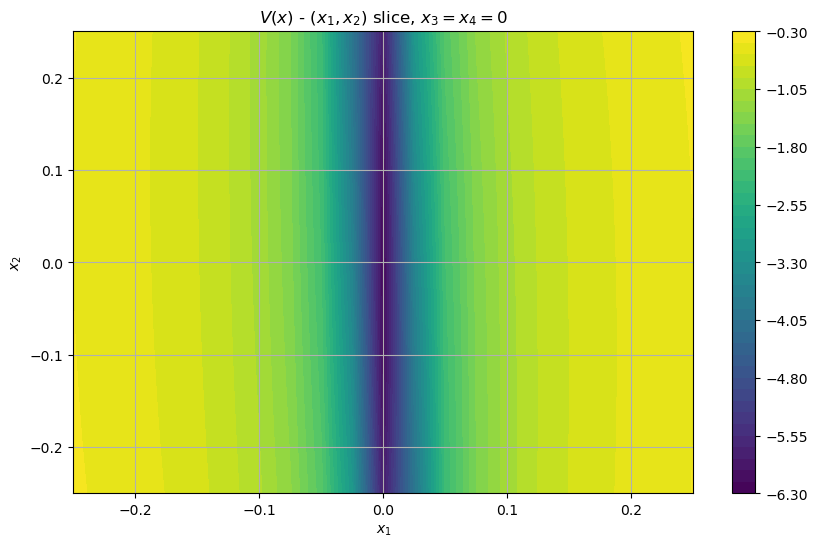

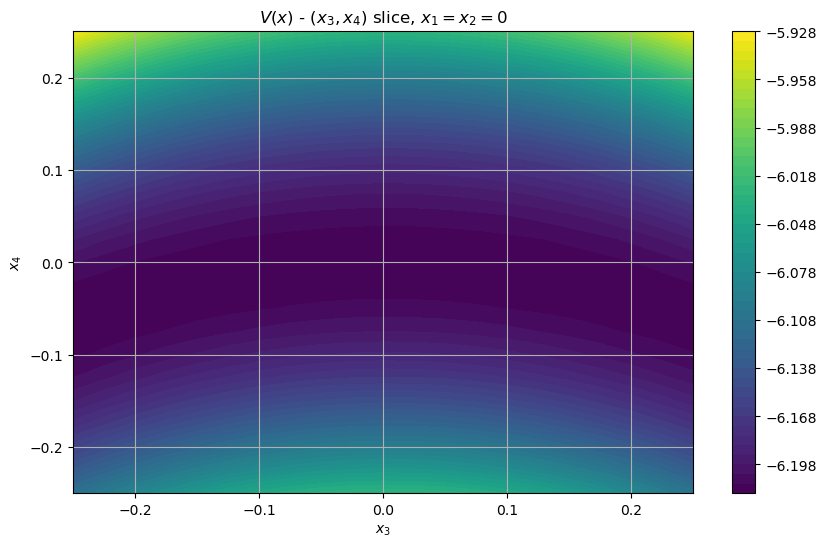

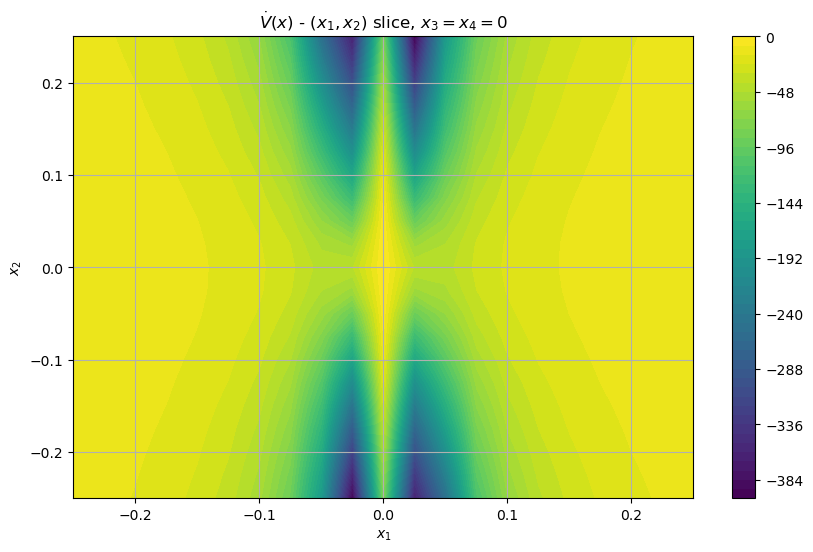

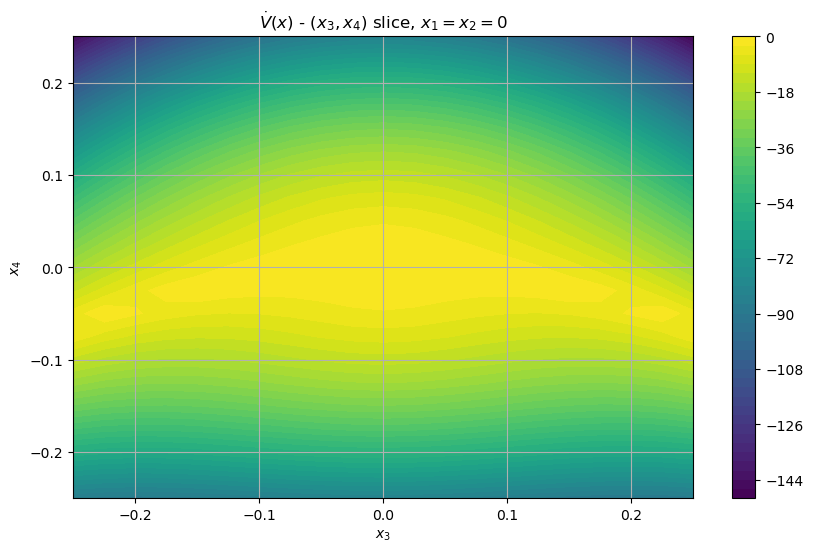

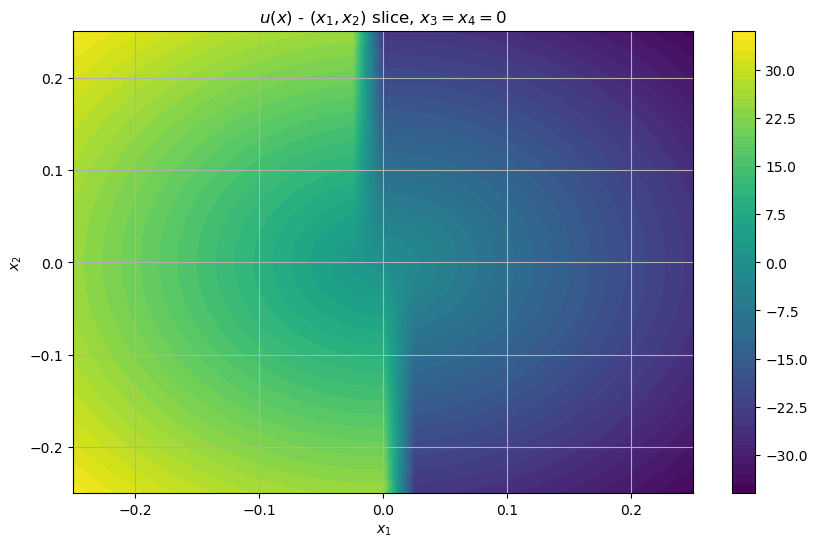

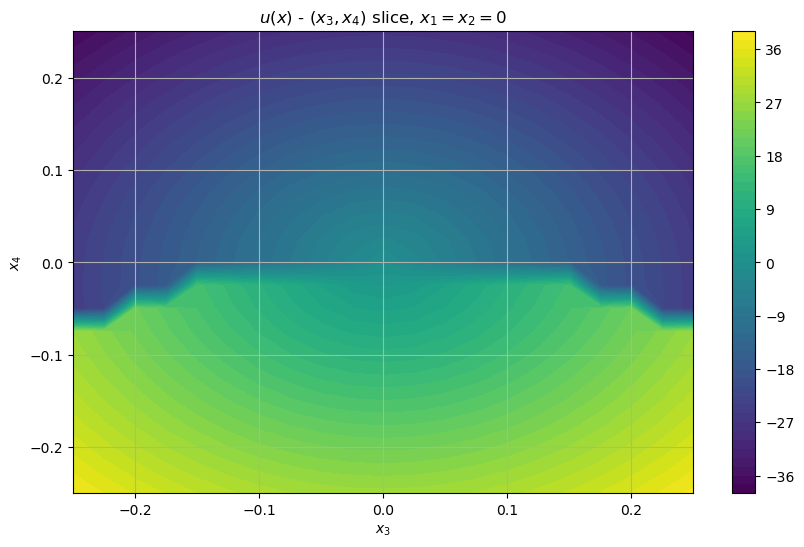

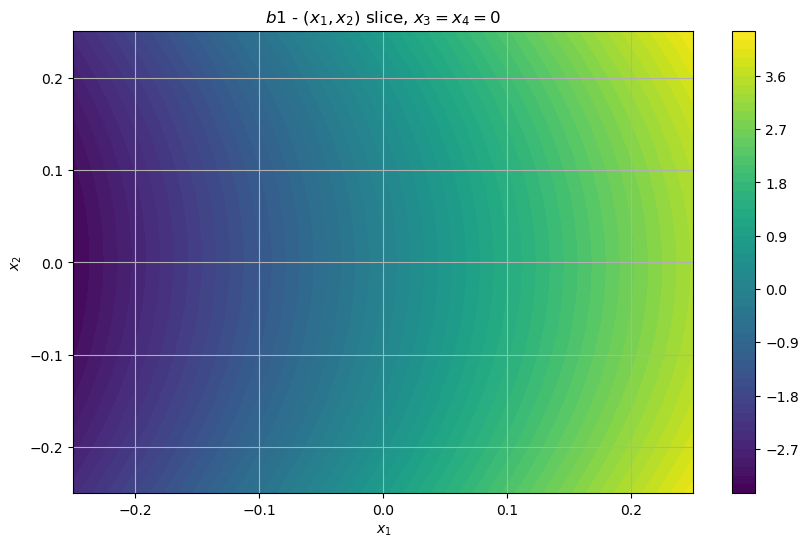

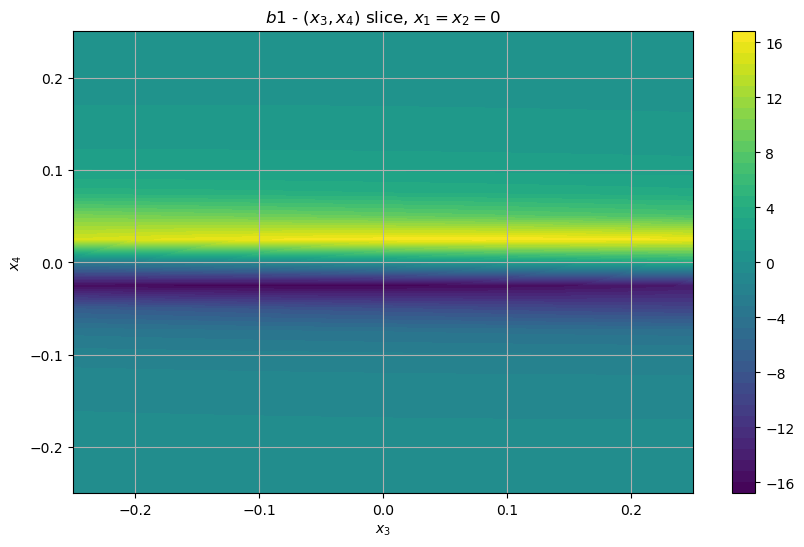

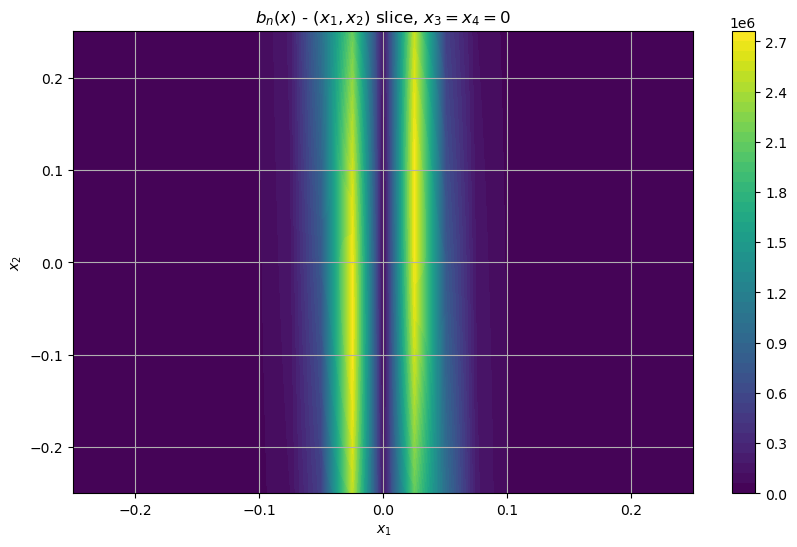

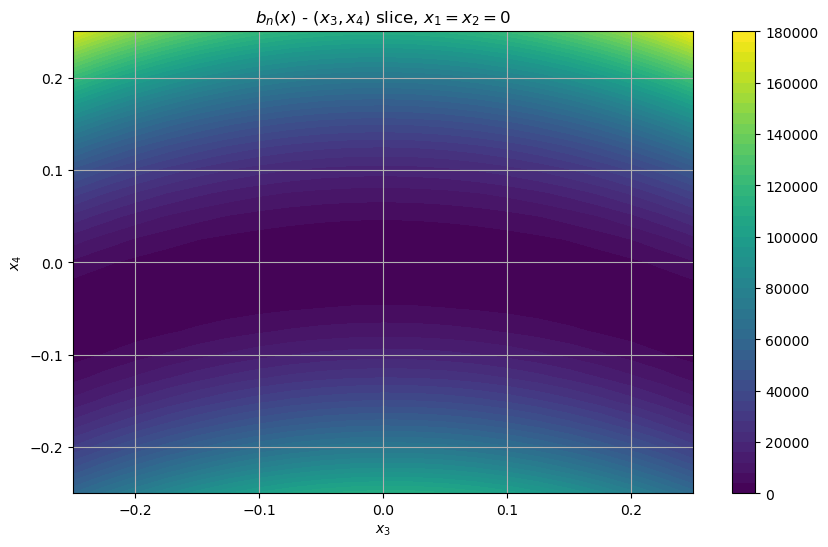

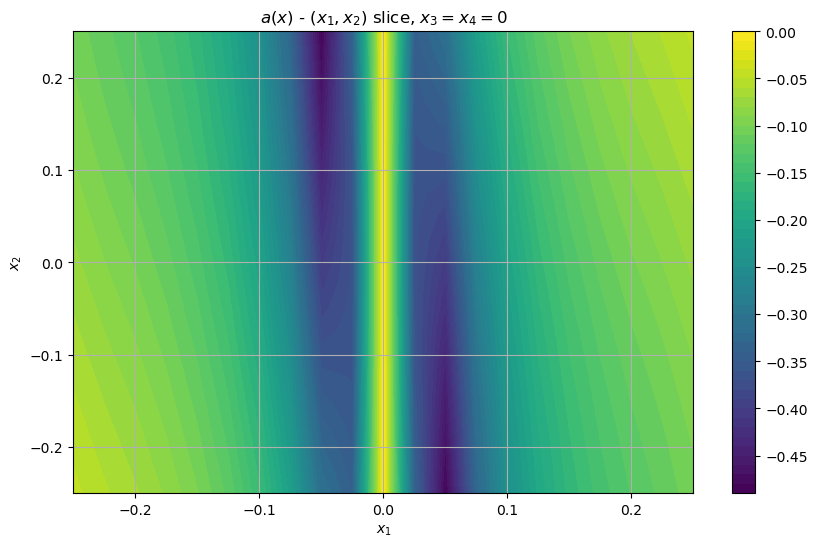

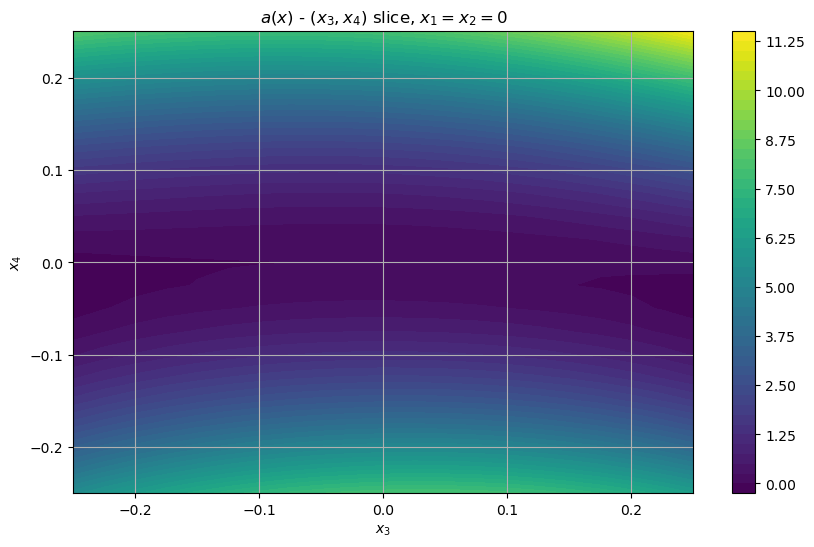

In [66]:
import matplotlib.pyplot as plt

center_idx = GRID_POINTS // 2

# Plot V(x1, x2) at x3 = 0, x4 = 0
plt.figure(figsize=(10, 6))
contour = plt.contourf(x1_vals, x2_vals, V_vals[:, :, center_idx, center_idx], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$V(x)$ - $(x_1, x_2)$ slice, $x_3=x_4=0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot V(x3, x4) at x1 = 0, x2 = 0
plt.figure(figsize=(10, 6))
contour = plt.contourf(x3_vals, x4_vals, V_vals[center_idx, center_idx, :, :], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$V(x)$ - $(x_3, x_4)$ slice, $x_1=x_2=0$")
plt.xlabel(r"$x_3$")
plt.ylabel(r"$x_4$")
plt.grid()
plt.show()

# Plot Vdot on the same two slices
plt.figure(figsize=(10, 6))
contour = plt.contourf(x1_vals, x2_vals, V_dot_vals[:, :, center_idx, center_idx], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$\dot V(x)$ - $(x_1, x_2)$ slice, $x_3=x_4=0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
contour = plt.contourf(x3_vals, x4_vals, V_dot_vals[center_idx, center_idx, :, :], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$\dot V(x)$ - $(x_3, x_4)$ slice, $x_1=x_2=0$")
plt.xlabel(r"$x_3$")
plt.ylabel(r"$x_4$")
plt.grid()
plt.show()

# Plot u_vals on the same two slices
plt.figure(figsize=(10, 6))
contour = plt.contourf(x1_vals, x2_vals, u_vals[:, :, center_idx, center_idx], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$u(x)$ - $(x_1, x_2)$ slice, $x_3=x_4=0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
contour = plt.contourf(x3_vals, x4_vals, u_vals[center_idx, center_idx, :, :], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$u(x)$ - $(x_3, x_4)$ slice, $x_1=x_2=0$")
plt.xlabel(r"$x_3$")
plt.ylabel(r"$x_4$")
plt.grid()
plt.show()

# Plot b1 on the same two slices
plt.figure(figsize=(10, 6))
contour = plt.contourf(x1_vals, x2_vals, b1[:, :, center_idx, center_idx], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b1$ - $(x_1, x_2)$ slice, $x_3=x_4=0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
contour = plt.contourf(x3_vals, x4_vals, b1[center_idx, center_idx, :, :], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b1$ - $(x_3, x_4)$ slice, $x_1=x_2=0$")
plt.xlabel(r"$x_3$")
plt.ylabel(r"$x_4$")
plt.grid()
plt.show()

# Plot b_nvals on the same two slices
plt.figure(figsize=(10, 6))
contour = plt.contourf(x1_vals, x2_vals, b_nvals[:, :, center_idx, center_idx], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b_n(x)$ - $(x_1, x_2)$ slice, $x_3=x_4=0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
contour = plt.contourf(x3_vals, x4_vals, b_nvals[center_idx, center_idx, :, :], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b_n(x)$ - $(x_3, x_4)$ slice, $x_1=x_2=0$")
plt.xlabel(r"$x_3$")
plt.ylabel(r"$x_4$")
plt.grid()
plt.show()

# Plot a_vals on the same two slices
plt.figure(figsize=(10, 6))
contour = plt.contourf(x1_vals, x2_vals, a_vals[:, :, center_idx, center_idx], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$a(x)$ - $(x_1, x_2)$ slice, $x_3=x_4=0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
contour = plt.contourf(x3_vals, x4_vals, a_vals[center_idx, center_idx, :, :], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$a(x)$ - $(x_3, x_4)$ slice, $x_1=x_2=0$")
plt.xlabel(r"$x_3$")
plt.ylabel(r"$x_4$")
plt.grid()
plt.show()


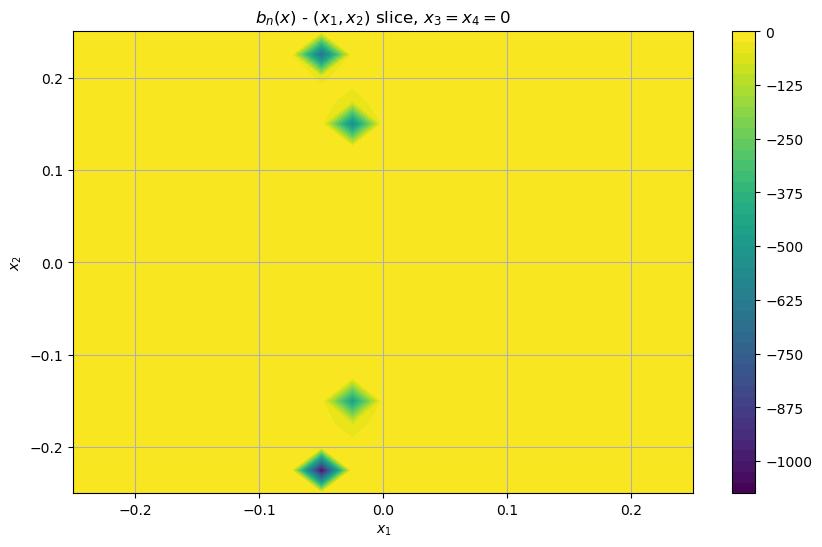

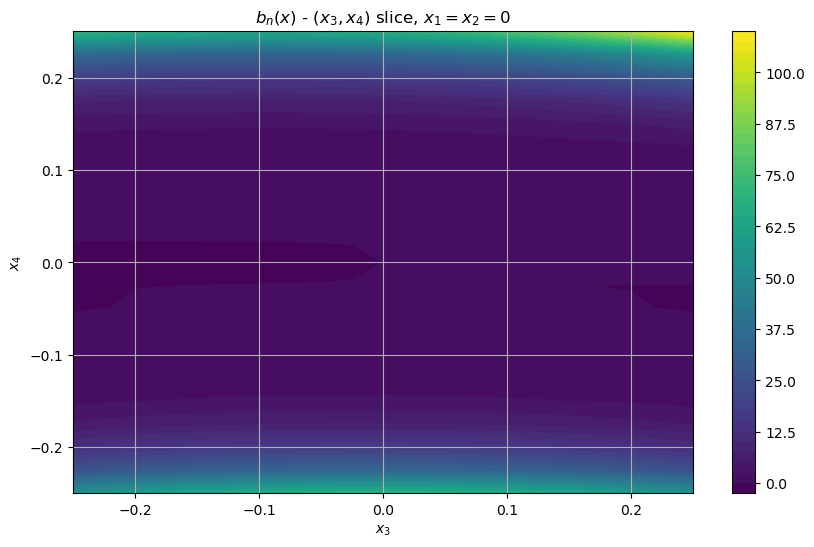

In [67]:
# Plot a_vals / b_nvals on the same two slices
plt.figure(figsize=(10, 6))
contour = plt.contourf(x1_vals, x2_vals, a_vals[:, :, center_idx, center_idx] / b1[:, :, center_idx, center_idx]**2, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b_n(x)$ - $(x_1, x_2)$ slice, $x_3=x_4=0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
contour = plt.contourf(x3_vals, x4_vals, a_vals[center_idx, center_idx, :, :] / b1[center_idx, center_idx, :, :]**2, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b_n(x)$ - $(x_3, x_4)$ slice, $x_1=x_2=0$")
plt.xlabel(r"$x_3$")
plt.ylabel(r"$x_4$")
plt.grid()
plt.show()

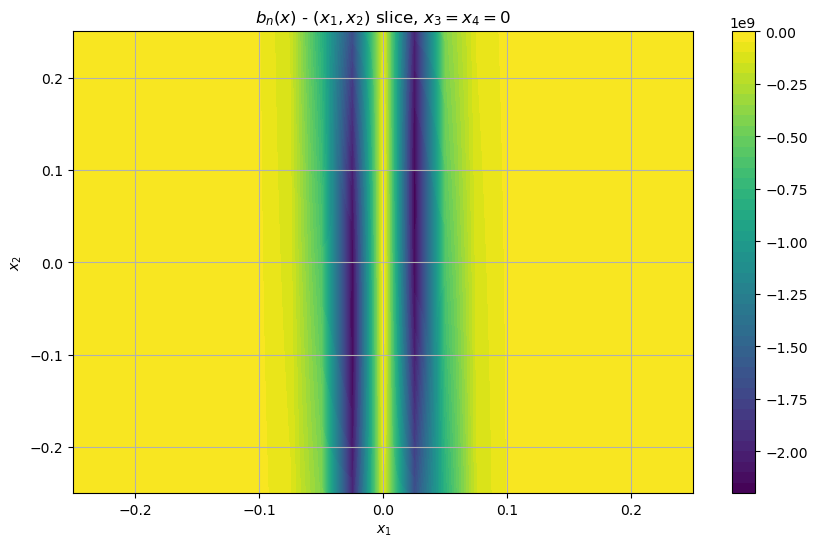

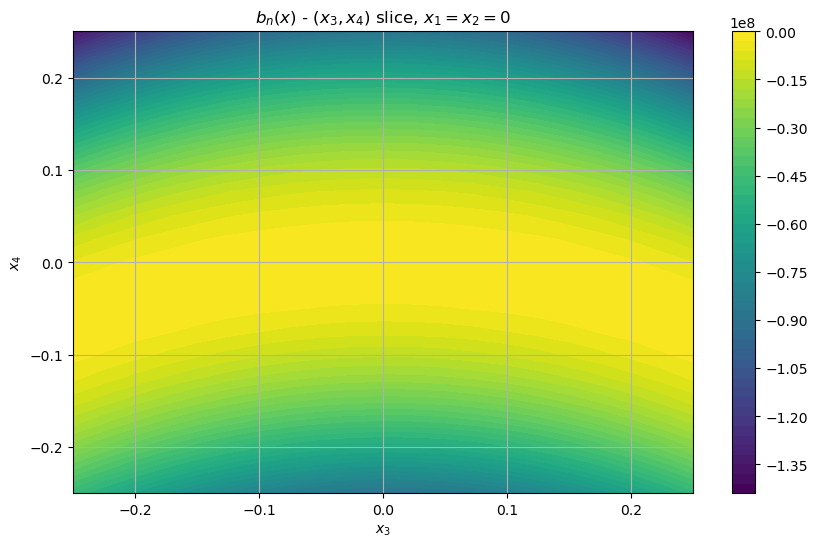

In [68]:
# Plot a_vals / b_nvals on the same two slices
plt.figure(figsize=(10, 6))
contour = plt.contourf(x1_vals, x2_vals, a_vals[:, :, center_idx, center_idx] - 800 *b_nvals[:, :, center_idx, center_idx], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b_n(x)$ - $(x_1, x_2)$ slice, $x_3=x_4=0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
contour = plt.contourf(x3_vals, x4_vals, a_vals[center_idx, center_idx, :, :] - 800 * b_nvals[center_idx, center_idx, :, :], levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b_n(x)$ - $(x_3, x_4)$ slice, $x_1=x_2=0$")
plt.xlabel(r"$x_3$")
plt.ylabel(r"$x_4$")
plt.grid()
plt.show()

In [69]:
print(np.max(a_vals - 80 * b_nvals))
print(np.min(a_vals - 80 * b_nvals))

-1.9548604320100852e-22
-222564436.89386737


In [70]:
print(np.max(a_vals - 80 * b1**2 * 10000))
print(np.min(a_vals - 80 * b1**2 * 10000))

-1.9548604320100852e-22
-222564435.8647778


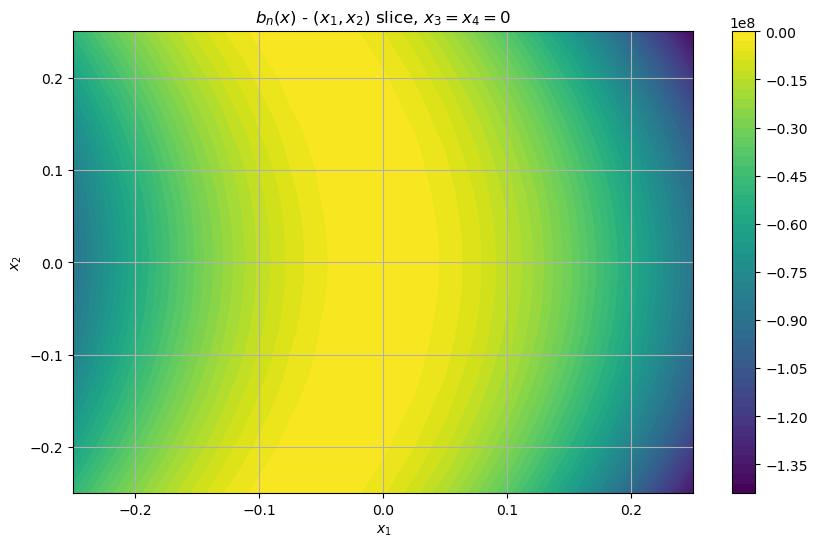

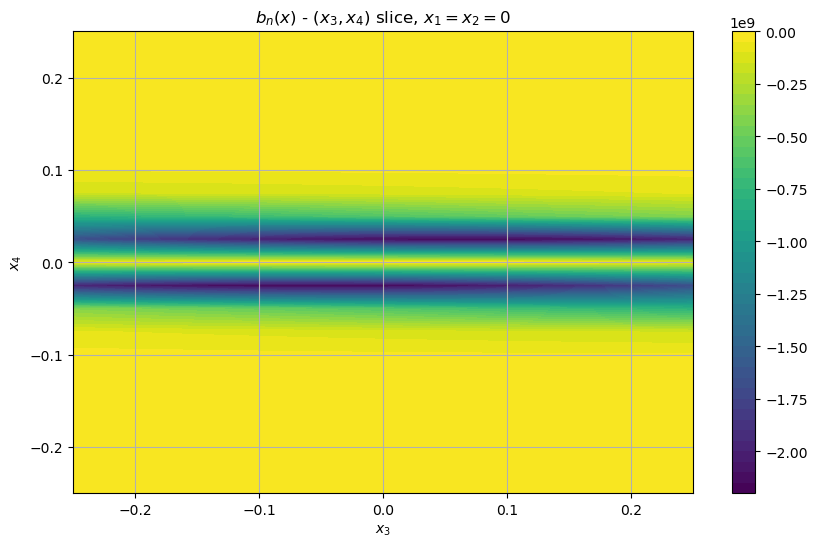

In [71]:
# Plot a_vals / b_nvals on the same two slices
plt.figure(figsize=(10, 6))
contour = plt.contourf(x1_vals, x2_vals, a_vals[:, :, center_idx, center_idx] - 800 * 10000 *b1[:, :, center_idx, center_idx]**2, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b_n(x)$ - $(x_1, x_2)$ slice, $x_3=x_4=0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
contour = plt.contourf(x3_vals, x4_vals, a_vals[center_idx, center_idx, :, :] - 800 * 10000 * b1[center_idx, center_idx, :, :]**2, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b_n(x)$ - $(x_3, x_4)$ slice, $x_1=x_2=0$")
plt.xlabel(r"$x_3$")
plt.ylabel(r"$x_4$")
plt.grid()
plt.show()

In [72]:
V = simplified_expr
x1, x2, x3, x4 = symbols('x1 x2 x3 x4')

x_vector = xSR(x1, x2, x3, x4)
f_vector = fSR(x1, x2, x3, x4)
G_matrix = GSR(x1, x2, x3, x4)
Q_matrix = QSR(x1, x2, x3, x4)
R_matrix = RSR(x1, x2, x3, x4)

x_syms = [x1, x2, x3, x4]

V_func, V_dot_func, lambda_func, u_func, u_func2, u_mag, b_norm_squared, b1, a = compute_v_and_v_dotSR(
    V, fSR, GSR, QSR, RSR, x_syms, None
)

# print(u_func)
# u_func


In [73]:
print(u_func)

(-40000.0*(0.5*x3*(2*cos(x2) - 2)*(-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**1.5 + 0.79474337497756261*(-0.3143580049734382*x3*(x2 + 7.372296470101777*exp(x4) + sin(x1))*cos(x2) - 0.3143580049734382*x3*sin(x2) + 3.910313370813341*(2*sin(x4) + 111.0044257409103*cos(x2))*(x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))/((x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))**2 + 1)**1.5)/(x1**2 + 1)**0.5)/(24 - 4*cos(x3)**2) - 20000.0*(-x3*(2.0*x2 - 4.0*x4 + 2.0*sin(x1) - 2.0*sin(x2) - 50.17636572694428)*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**1.5 - x3*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**0.5 - x3*exp(x4)*cos(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**0.5 + 0.79474337497756261*(-2.317540410413916*x3*exp(x4)*sin(x2) + 3.910313370813341*(2*(x2 + x4 + sin(x1))*cos(x4) 

In [74]:
print(b1)
print(a)

4*(0.5*x3*(2*cos(x2) - 2)*(-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**1.5 + 0.79474337497756261*(-0.3143580049734382*x3*(x2 + 7.372296470101777*exp(x4) + sin(x1))*cos(x2) - 0.3143580049734382*x3*sin(x2) + 3.910313370813341*(2*sin(x4) + 111.0044257409103*cos(x2))*(x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))/((x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))**2 + 1)**1.5)/(x1**2 + 1)**0.5)/(24 - 4*cos(x3)**2) + 2*(-x3*(2.0*x2 - 4.0*x4 + 2.0*sin(x1) - 2.0*sin(x2) - 50.17636572694428)*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**1.5 - x3*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**0.5 - x3*exp(x4)*cos(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**0.5 + 0.79474337497756261*(-2.317540410413916*x3*exp(x4)*sin(x2) + 3.910313370813341*(2*(x2 + x4 + sin(x1))*cos(x4) + 2*sin(x4))*(

In [75]:
# u_func

In [76]:
#u_func3 = -1000*((a + sqrt(a**2 + b_norm_squared[0]**2))/sqrt(1 + b_norm_squared[0]**2))*b_norm_squared[2]
#u_func3

In [77]:
# from dreal import *
# from sympy import symbols
# from src.dreal_clf_verification import _sympy_to_dreal
# import dreal

# x1, x2, x3, x4 = symbols("x1 x2 x3 x4")
# x_syms = [x1, x2, x3, x4]

# xd = {s: Variable(str(s)) for s in x_syms}

# a_d = _sympy_to_dreal(a, xd, dreal)

# b_expr = b_norm_squared[0]**0.5
# b_d = _sympy_to_dreal(b_expr, xd, dreal)

# origin_radius = 1e-3
# b_tol = 1e-4
# a_tol = -1e-8
# delta = 1e-3

# r2 = sum(xd[s] * xd[s] for s in x_syms)

# query = And(
#     -0.25 <= xd[x1], xd[x1] <= 0.25,
#     xd[x1] <= 0.25,
#     -0.25 <= xd[x2], xd[x2] <= 0.25,
#     -0.25 <= xd[x3], xd[x3] <= 0.25,
#     -0.25 <= xd[x4], xd[x4] <= 0.25,

#     r2 >= origin_radius**2,

#     0 <= b_d, b_d <= b_tol,

#     a_d >= -a_tol,
# )

# result = CheckSatisfiability(query, delta)
# result

In [78]:

# import sympy as sp
# from sympy import simplify

# # Define variables
# x1, x2, x3, x4 = symbols('x1 x2 x3 x4')

# # Define expression (replace with your actual function)
# expr = V_func
# expr = simplify(expr)
# # Round coefficients to 2 decimal places
# expr_rounded = expr.xreplace({n: round(n, 3) for n in expr.atoms(sp.Number)})

# # Convert to LaTeX
# latex_expr = sp.latex(expr_rounded)

# # Print LaTeX expression
# print(latex_expr)


In [79]:
# b_norm_squared

In [80]:
# b_norm_squared[0]

In [81]:
from sympy import symbols, Function, Matrix, Eq, dsolve
from SystemDynamics import f, G, Q, R
from src.NumSol import NumSol
import matplotlib.pyplot as plt

In [82]:
# # IBEX: maximize a - CLF_RHO*|b|^2 with the live notebook expressions.
# from pathlib import Path
# import subprocess
# import sys
# import Evaluate

# print(b1)
# print(a)

# IBEX_DIR = Path(EXAMPLE_DIR).parent / 'Test4Ibex'
# MODEL = IBEX_DIR / 'clf_barrier_margin.mbx'
# rho = float(Evaluate.CLF_RHO)

# def _minibex_expression(expr):
#     return str(expr).replace('**', '^')

# b_mbx = _minibex_expression(b1)
# a_mbx = _minibex_expression(a)

# MODEL.write_text(
#     f"""Constants
#   eps = 1e-5;
#   rho = {rho:.17g};

# Variables
#   x1 in [-0.25, 0.25];
#   x2 in [-0.25, 0.25];
#   x3 in [-0.25, 0.25];
#   x4 in [-0.25, 0.25];

# function bfun(x1, x2, x3, x4)
#   return {b_mbx};
# end

# function afun(x1, x2, x3, x4)
#   return {a_mbx};
# end

# function barrierfun(x1, x2, x3, x4)
#   // b is scalar, so b^2 = |b|^2.
#   return afun(x1, x2, x3, x4) - rho*bfun(x1, x2, x3, x4)^2;
# end

# function barrier_marginfun(x1, x2, x3, x4)
#   return barrierfun(x1, x2, x3, x4);
# end

# Minimize
#   -barrier_marginfun(x1, x2, x3, x4);

# Constraints
#   x1^2 + x2^2 + x3^2 + x4^2 >= eps^2;
# end
# """,
#     encoding='utf-8',
# )

# subprocess.run(
#     [sys.executable, 'run_barrier_parallel_12.py', '--timeout', '10'],
#     cwd=IBEX_DIR,
#     check=False,
# )


In [83]:
x1, x2, x3, x4 = symbols('x1 x2 x3 x4')

from sympy import symbols, lambdify, diff, Matrix, sin, cos, exp, log, sqrt, tanh

T = 10
x0 = [0.0, 0.0, 0.01, 0.01]
# x0 = [0.1, 0.0, 0.0, 0.00]

# x0 = [-0.0, 0.01, 0.000, 0.0]


In [84]:
v = lambdify((x1, x2, x3, x4), V_func, 'numpy')
v(0.001, 0.001, 0.001, 0.001)

np.float64(-6.205138811591982)

In [85]:
vdot = lambdify((x1, x2, x3, x4), V_dot_func, 'numpy')
vdot(0.001, 0.001, 0.001, 0.001)

np.float64(-0.7903773292426984)

In [86]:
u_func_LQR = -1.0e+03 * (-0.1000 * x1 + -0.1832 * x2 + 1.6832* x3 + 0.6466* x4)
t_vals_L, x_vals_L = NumSol(u_func_LQR, T, x0, fSR, GSR, None, TRQlim)

#u_func_NN = 20 * tanh(-23.28 * x1  -5.27 * x2) / 26.6 
#t_vals_N, x1_vals_N, x2_vals_N = NumSol(u_func_NN, T, x1_0, x2_0, None, TRQlim)

#u_func_CLF = (-68*x1 - 144*x2)*(sqrt((68*x1 + 144*x2)**2*(x1**2 + x2**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))/(68*x1 + 144*x2)**2)
u_func_CLF = u_func * 1
#-1.0e+03 * (-0.1000 * (x1) + -0.1832 * x2 + 1.6832* x3 + 0.6466* x4) 
t_vals_C, x_vals_C, = NumSol(u_func_CLF, T, x0, fSR, GSR, None, TRQlim)


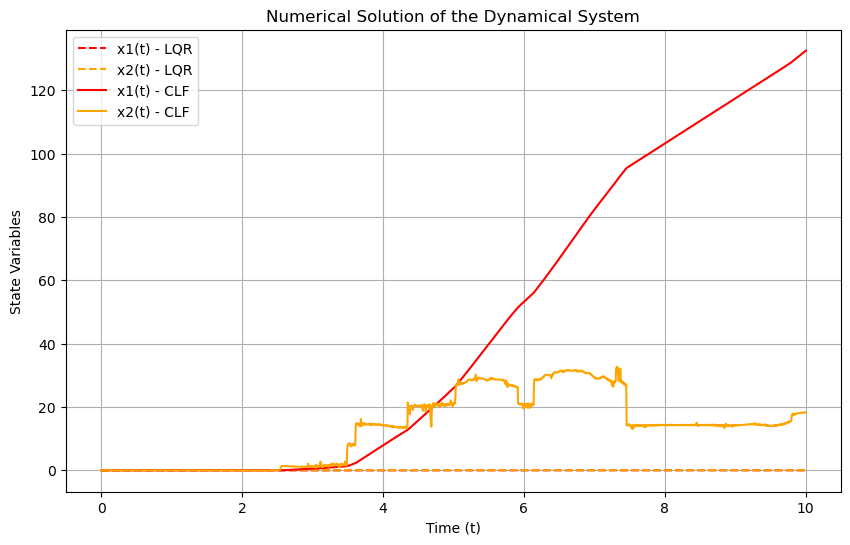

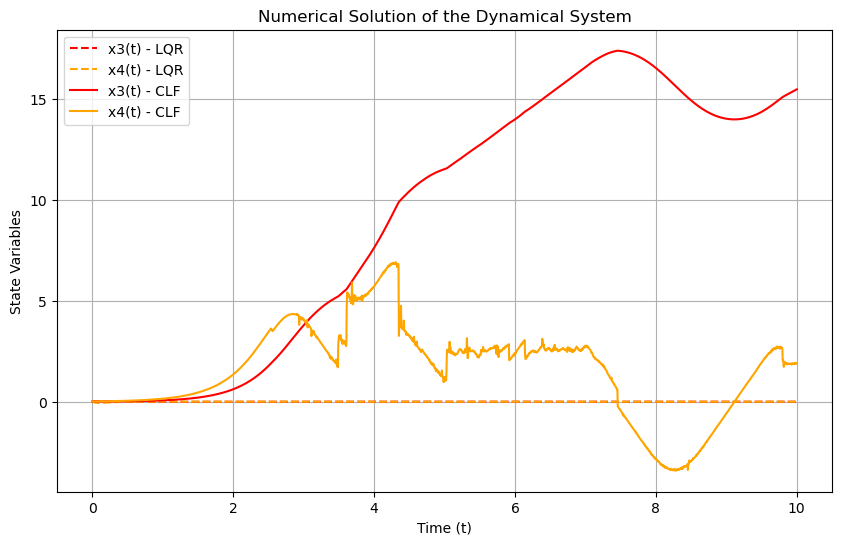

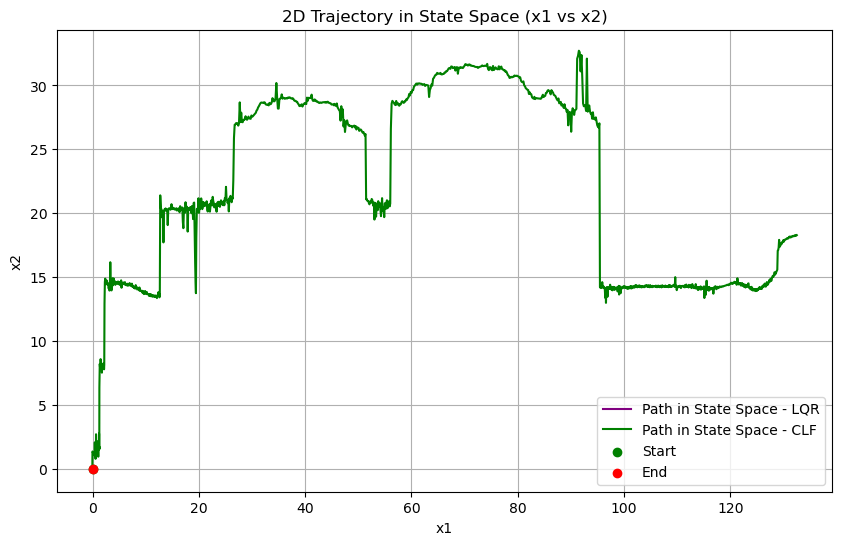

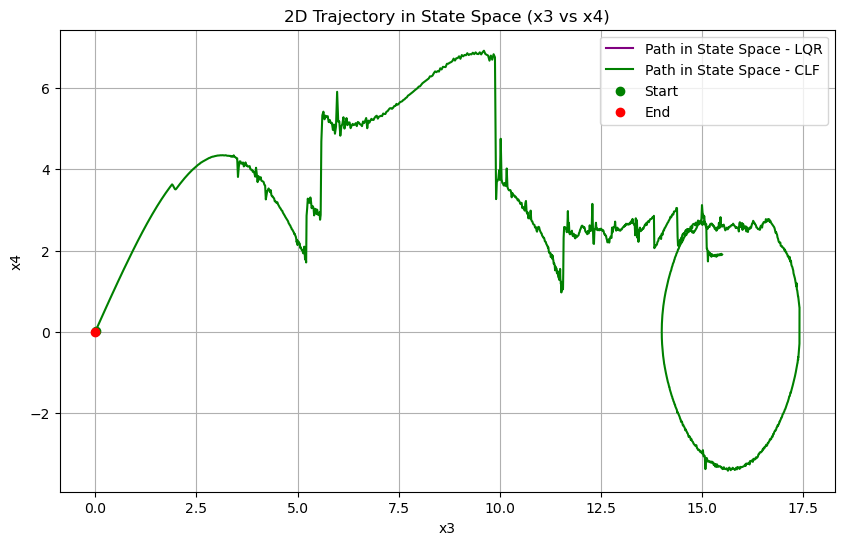

In [87]:
# Plot the solution
plt.figure(figsize=(10, 6))

plt.plot(t_vals_L, x_vals_L[0], label="x1(t) - LQR", color="red", linestyle='--')
plt.plot(t_vals_L, x_vals_L[1], label="x2(t) - LQR", color="orange", linestyle='--')

#plt.plot(t_vals_N, x1_vals_N, label="x1(t) - NN", color="red", linestyle=':')
#plt.plot(t_vals_N, x2_vals_N, label="x2(t) - NN", color="orange", linestyle=':')

plt.plot(t_vals_C, x_vals_C[0], label="x1(t) - CLF", color="red")
plt.plot(t_vals_C, x_vals_C[1], label="x2(t) - CLF", color="orange")
'''
plt.plot(time[0:10], x_list[0:10, 0], label="x1(t) - MCP", color="red", linestyle='-.')
plt.plot(time[0:10], x_list[0:10, 1], label="x2(t) - MPC", color="orange", linestyle='-.')
'''
plt.xlabel("Time (t)")
plt.ylabel("State Variables")
plt.legend()
plt.title("Numerical Solution of the Dynamical System")
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))

plt.plot(t_vals_L, x_vals_L[2], label="x3(t) - LQR", color="red", linestyle='--')
plt.plot(t_vals_L, x_vals_L[3], label="x4(t) - LQR", color="orange", linestyle='--')

#plt.plot(t_vals_N, x1_vals_N, label="x1(t) - NN", color="red", linestyle=':')
#plt.plot(t_vals_N, x2_vals_N, label="x2(t) - NN", color="orange", linestyle=':')

plt.plot(t_vals_C, x_vals_C[2], label="x3(t) - CLF", color="red")
plt.plot(t_vals_C, x_vals_C[3], label="x4(t) - CLF", color="orange")
'''
plt.plot(time[0:10], x_list[0:10, 0], label="x1(t) - MCP", color="red", linestyle='-.')
plt.plot(time[0:10], x_list[0:10, 1], label="x2(t) - MPC", color="orange", linestyle='-.')
'''
plt.xlabel("Time (t)")
plt.ylabel("State Variables")
plt.legend()
plt.title("Numerical Solution of the Dynamical System")
plt.grid()
plt.show()

######################################################################################
######################################################################################

# Plot the 2D trajectory (state space path)
plt.figure(figsize=(10, 6))

plt.plot(x_vals_L[0], x_vals_L[1], label="Path in State Space - LQR", color="purple")
#plt.plot(x1_vals_N, x2_vals_N, label="Path in State Space - NN", color="red")
plt.plot(x_vals_C[0], x_vals_C[1], label="Path in State Space - CLF", color="green")
'''
plt.plot(x_list[:, 0], x_list[:, 1], label="Path in State Space - MPC", color="b")
'''
plt.scatter(x0[0], x0[1], color="green", label="Start", zorder=5)  # Start point
plt.scatter(0, 0, color="red", label="End", zorder=5)  # End point

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Trajectory in State Space (x1 vs x2)")
plt.legend()
plt.grid()
plt.show()

# Plot the 2D trajectory (state space path)
plt.figure(figsize=(10, 6))

plt.plot(x_vals_L[2], x_vals_L[3], label="Path in State Space - LQR", color="purple")
#plt.plot(x1_vals_N, x2_vals_N, label="Path in State Space - NN", color="red")
plt.plot( x_vals_C[2], x_vals_C[3], label="Path in State Space - CLF", color="green")
'''
plt.plot(x_list[:, 0], x_list[:, 1], label="Path in State Space - MPC", color="b")
'''
plt.scatter(x0[2], x0[3], color="green", label="Start", zorder=5)  # Start point
plt.scatter(0, 0, color="red", label="End", zorder=5)  # End point

plt.xlabel("x3")
plt.ylabel("x4")
plt.title("2D Trajectory in State Space (x3 vs x4)")
plt.legend()
plt.grid()
plt.show()

In [88]:
from src.CostFunction import calculate_cost

# Calculate the cost
cost_LQR, cost_LQR1, cost_LQR2, u_val_LQR = calculate_cost(t_vals_L, x_vals_L, u_func_LQR, GSR, Q, R, None,TRQlim, 0)
print("Total cost for LQR:", cost_LQR1, cost_LQR2, cost_LQR)

#cost_NN, cost_NN1, cost_NN2, u_val_NN = calculate_cost(t_vals_N, x1_vals_N, x2_vals_N, u_func_NN, None, TRQlim, 0)
#print("Total cost for NN:", cost_NN1, cost_NN2[0][0], cost_NN[0][0])

cost_CLF, cost_CLF1, cost_CLF2, u_val_CLF = calculate_cost(t_vals_C, x_vals_C, u_func_CLF, GSR, Q, R, None, TRQlim, 0)
print("Total cost for CLF:", cost_CLF1, cost_CLF2, cost_CLF)

Total cost for LQR: 0.00948861140952288 0.001199815712704996 0.01068842712222783
Total cost for CLF: 47569.50520678907 7156943.824077067 7204513.329283856


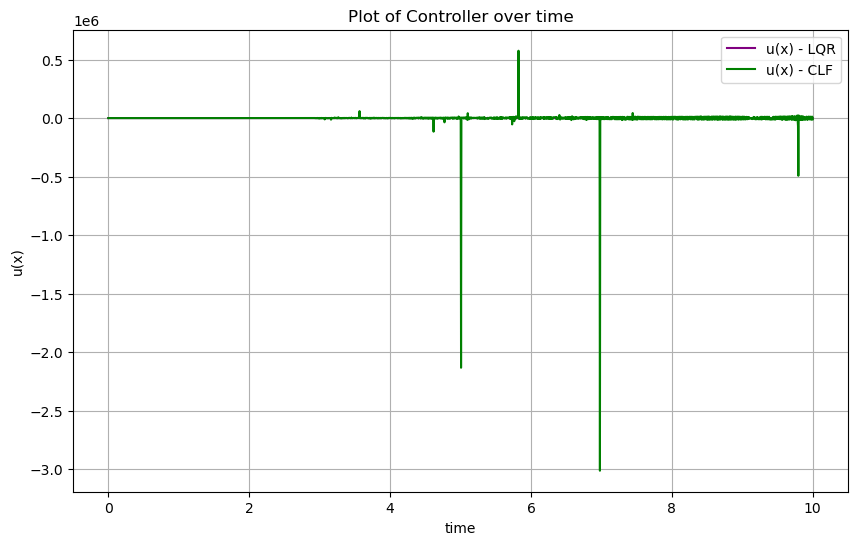

In [89]:
plt.figure(figsize=(10, 6))
plt.plot(t_vals_L, u_val_LQR[:, 1], label="u(x) - LQR", color="purple")
#plt.plot(t_vals_N, u_val_NN[:, 1], label="u(x) - NN", color="red")
plt.plot(t_vals_C, u_val_CLF[:, 1], label="u(x) - CLF", color="green")
plt.xlabel("time")
plt.ylabel("u(x)")
plt.title("Plot of Controller over time")
plt.legend()
plt.grid()
plt.show()

In [90]:
x_vals_C[2][-1]

np.float64(15.492917201966147)

current CLF : c_box=0.00000  c_viol=inf  -> c_cert=0.00000  (covers 0.00% of box)
LQR ref     : c_box=0.00424  c_viol=0.00017  -> c_cert=0.00017  (covers 0.00% of box)


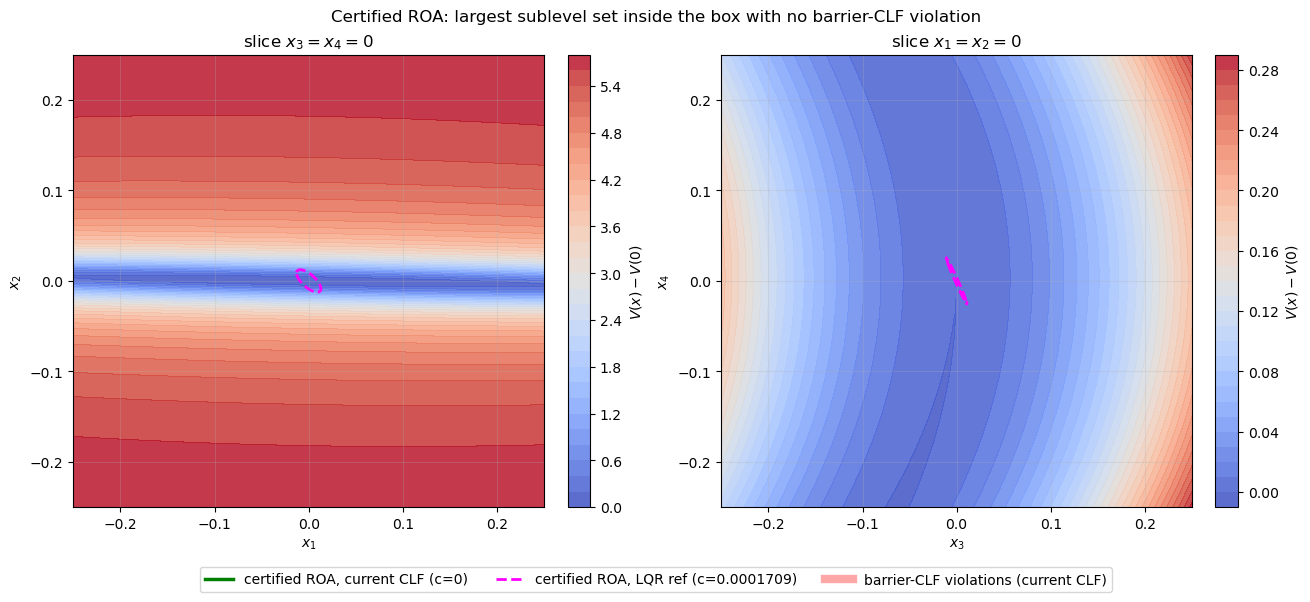

In [91]:
# === Certified ROA estimate and plot ===
# ROA = largest sublevel set {V - V(0) <= c_cert} that
#   (i)  fits inside the verification box        -> c_box
#   (ii) contains no barrier-CLF violation inside -> c_viol
#        a(x) - CLF_RHO*|b(x)| + CLF_GAMMA1 < DECAY_TOL
# This matches the current bounded-input DE/SHGO condition.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sympy import lambdify
import Evaluate
from SystemDynamics import f as _ffn, G as _Gfn, R as _Rfn
from src import clf_checks

_r = float(np.asarray(_Rfn(0.0, 0.0, 0.0, 0.0))[1, 1])

# Local replacements for the old EvaluatePrime helpers. Keep these explicit so
# this notebook does not depend on a missing EvaluatePrime.py module.
CLF_RHO = float(getattr(Evaluate, "CLF_RHO", 800.0))
CLF_GAMMA1 = float(getattr(Evaluate, "CLF_GAMMA1", 0.0))
DECAY_TOL = float(getattr(Evaluate, "DECAY_TOL", 0.0))
ORIGIN_EXCLUDE_RADIUS = float(getattr(Evaluate, "CLF_ORIGIN_EXCLUDE_RADIUS", 1.1e-3))


def _boundary_min(V_rel):
    return clf_checks.boundary_min(V_rel)


def _dynamics_on_grid(true_data, mesh):
    return clf_checks.dynamics_on_grid(true_data, mesh, _ffn, _Gfn, input_index=1)


def _certified_level(V_grid, V0, a_grid, b_abs_grid, mesh):
    V_rel = V_grid - V0
    c_box = max(_boundary_min(V_rel), 0.0)
    barrier_margin = a_grid - CLF_RHO * b_abs_grid **2 # + CLF_GAMMA1
    r2 = sum(m**2 for m in mesh)
    viol = (
        (r2 > ORIGIN_EXCLUDE_RADIUS**2)
        & (barrier_margin >= DECAY_TOL)
        & (V_rel > 0.0)
        & (V_rel < c_box)
    )
    c_viol = float(V_rel[viol].min()) if np.any(viol) else np.inf
    c_cert = max(min(c_box, c_viol), 0.0)
    frac = float(np.mean(V_rel <= c_cert)) if c_cert > 0 else 0.0
    return V_rel, barrier_margin, c_box, c_viol, c_cert, frac


# --- current expression (grid quantities from the earlier cells) ---
V0_cur = float(simplified_expr.subs({x1: 0, x2: 0, x3: 0, x4: 0}))
b_abs_cur = np.sqrt(np.maximum(b_nvals, 0.0) * _r)  # |b|, single active input
V_rel_cur, margin_cur, c_box_cur, c_viol_cur, c_cert_cur, frac_cur = _certified_level(
    V_vals, V0_cur, a_vals, b_abs_cur, train_data.mesh
)

# --- LQR reference quadratic, same treatment ---
lqr_expr = (
    1.965366*x1**2 + 2.862562*x1*x2 - 13.368898*x1*x3 - 5.925124*x1*x4 + 2.143945*x2**2 - 20.349648*x2*x3 - 8.970854*x2*x4 + 50.818966*x3**2 + 43.681856*x3*x4 + 9.639298*x4**2
)
_lqr_f = lambdify((x1, x2, x3, x4), lqr_expr, "numpy")
V_lqr = np.asarray(_lqr_f(*train_data.mesh), dtype=float)
_grads = np.gradient(V_lqr, *x_vals, edge_order=2)
_fvec, _gcol = _dynamics_on_grid(train_data, train_data.mesh)
a_lqr = sum(g * fc for g, fc in zip(_grads, _fvec))
b_abs_lqr = np.abs(sum(g * gc for g, gc in zip(_grads, _gcol)))
V_rel_lqr, _, c_box_lqr, c_viol_lqr, c_cert_lqr, frac_lqr = _certified_level(
    V_lqr, 0.0, a_lqr, b_abs_lqr, train_data.mesh
)

print(
    f"current CLF : c_box={c_box_cur:.5f}  c_viol={c_viol_cur:.5f}  "
    f"-> c_cert={c_cert_cur:.5f}  (covers {100*frac_cur:.2f}% of box)"
)
print(
    f"LQR ref     : c_box={c_box_lqr:.5f}  c_viol={c_viol_lqr:.5f}  "
    f"-> c_cert={c_cert_lqr:.5f}  (covers {100*frac_lqr:.2f}% of box)"
)

# --- dense slices for smooth level sets ---
_V_cur_f = lambdify((x1, x2, x3, x4), simplified_expr, "numpy")
_ss = np.linspace(-0.25, 0.25, 300)
S1, S2 = np.meshgrid(_ss, _ss, indexing="ij")
Z0 = np.zeros_like(S1)
center = GRID_POINTS // 2

slice_defs = [
    (r"$x_1$", r"$x_2$", (S1, S2, Z0, Z0), x1_vals, x2_vals,
     (slice(None), slice(None), center, center), r"slice $x_3=x_4=0$"),
    (r"$x_3$", r"$x_4$", (Z0, Z0, S1, S2), x3_vals, x4_vals,
     (center, center, slice(None), slice(None)), r"slice $x_1=x_2=0$"),
]

viol_grid = (margin_cur >= DECAY_TOL) & (V_rel_cur > 0.0) & (V_rel_cur < c_box_cur)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
for ax, (xl, yl, args, gx, gy, idx, title) in zip(axes, slice_defs):
    Vs = np.asarray(_V_cur_f(*args), dtype=float) - V0_cur
    Vl = np.asarray(_lqr_f(*args), dtype=float)

    cs = ax.contourf(S1, S2, Vs, levels=30, cmap="coolwarm", alpha=0.85)
    fig.colorbar(cs, ax=ax, label=r"$V(x)-V(0)$")

    if np.isfinite(c_cert_cur) and c_cert_cur > 0:
        ax.contour(S1, S2, Vs, levels=[c_cert_cur], colors="green", linewidths=2.5)
    if np.isfinite(c_cert_lqr) and c_cert_lqr > 0:
        ax.contour(S1, S2, Vl, levels=[c_cert_lqr], colors="magenta",
                   linestyles="--", linewidths=2.0)

    sl = viol_grid[idx]
    if np.any(sl):
        ax.contourf(gx, gy, sl.T.astype(float), levels=[0.5, 1.5],
                    colors="red", alpha=0.35)

    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title)
    ax.grid(alpha=0.25)

fig.legend(
    handles=[
        Line2D([], [], color="green", lw=2.5,
               label=f"certified ROA, current CLF (c={c_cert_cur:.4g})"),
        Line2D([], [], color="magenta", ls="--", lw=2,
               label=f"certified ROA, LQR ref (c={c_cert_lqr:.4g})"),
        Line2D([], [], color="red", lw=6, alpha=0.35,
               label="barrier-CLF violations (current CLF)"),
    ],
    loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08),
)
fig.suptitle(
    "Certified ROA: largest sublevel set inside the box "
    "with no barrier-CLF violation"
)
plt.show()


In [92]:
# import pygame
# import numpy as np
# import imageio
# import cv2

# # Pygame Setup
# WIDTH, HEIGHT = 800, 600
# WHITE = (255, 255, 255)
# BLACK = (0, 0, 0)
# RED = (200, 0, 0)
# BLUE = (0, 0, 200)
# FPS = 60

# # Pendulum and cart dimensions
# l_pixels = 150  # Pendulum length in pixels
# cart_width = 100
# cart_height = 40

# # Scaling for cart position (physical x to screen x)
# scale = 100  # pixels per meter

# # Initialize pygame
# pygame.init()
# screen = pygame.display.set_mode((WIDTH, HEIGHT))
# clock = pygame.time.Clock()

# # Video Writer Setup
# output_video = "cartpole_animation.mp4"
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')
# video_writer = cv2.VideoWriter(output_video, fourcc, FPS, (WIDTH, HEIGHT))

# # Prepare to Save Frames
# frames = []
# durations = []

# # Simulation Variables
# frame_index = 0
# origin_y = HEIGHT // 2 + 100  # Vertical base line for cart track

# # Simulation Loop
# running = True
# while running:
#     screen.fill(WHITE)

#     for event in pygame.event.get():
#         if event.type == pygame.QUIT:
#             running = False

#     if frame_index < len(x_vals_C[0]) - 1:
#         x_cart = x_vals_C[0][frame_index]  # Cart position (meters)
#         theta = x_vals_C[2][frame_index]   # Pole angle (radians, from upright)
#         frame_index += 1
#     else:
#         running = False
#     theta = theta + np.pi
#     # Screen coordinates
#     cart_x_screen = int(WIDTH // 2 + x_cart * scale)
#     cart_y_screen = origin_y

#     # Draw cart
#     cart_rect = pygame.Rect(0, 0, cart_width, cart_height)
#     cart_rect.center = (cart_x_screen, cart_y_screen)
#     pygame.draw.rect(screen, BLUE, cart_rect)

#     # Attach pole to center-top of cart
#     pivot_x = cart_x_screen
#     pivot_y = cart_y_screen #- cart_height // 2
#     pend_x = int(pivot_x + l_pixels * np.sin(theta))
#     pend_y = int(pivot_y + l_pixels * np.cos(theta))

#     # Draw pendulum
#     pygame.draw.line(screen, BLACK, (pivot_x, pivot_y), (pend_x, pend_y), 5)
#     pygame.draw.circle(screen, RED, (pend_x, pend_y), 12)

#     pygame.display.flip()
#     clock.tick(FPS)

#     # Save frame
#     #frame = pygame.surfarray.array3d(screen)
#     #frame = np.fliplr(frame)
#     #frame = np.rot90(frame)
#     #frame = np.ascontiguousarray(frame)
#     #frames.append(frame)
#     #durations.append(1000 / FPS)
#     #frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
#     #video_writer.write(frame_bgr)

# pygame.quit()
# '''
# # Save GIF and video
# imageio.mimsave("cartpole_animation.gif", frames, duration=[d / 1000 for d in durations])
# print("GIF saved as 'cartpole_animation.gif'.")
# video_writer.release()
# print(f"Video saved as '{output_video}' with {FPS} FPS.")
# '''

In [93]:
# # Optional comparison against external cart-pendulum data.
# # The original V3 notebook expected cart_pendulum_wocontroller.txt in the working directory.
# # Keep this cell disabled unless that data file is present.

# import os
# import matplotlib.pyplot as plt
# import pandas as pd

# path = os.path.join(EXAMPLE_DIR, 'cart_pendulum_wocontroller.txt')
# if os.path.exists(path):
#     data_ctrl = pd.read_csv(path, sep='	', header=None)
#     display(data_ctrl.head())
# else:
#     print("External comparison file not found:", path)


### V

<IPython.core.display.Math object>

############

Corresponding slice functions, with each fixed pair set to zero:

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

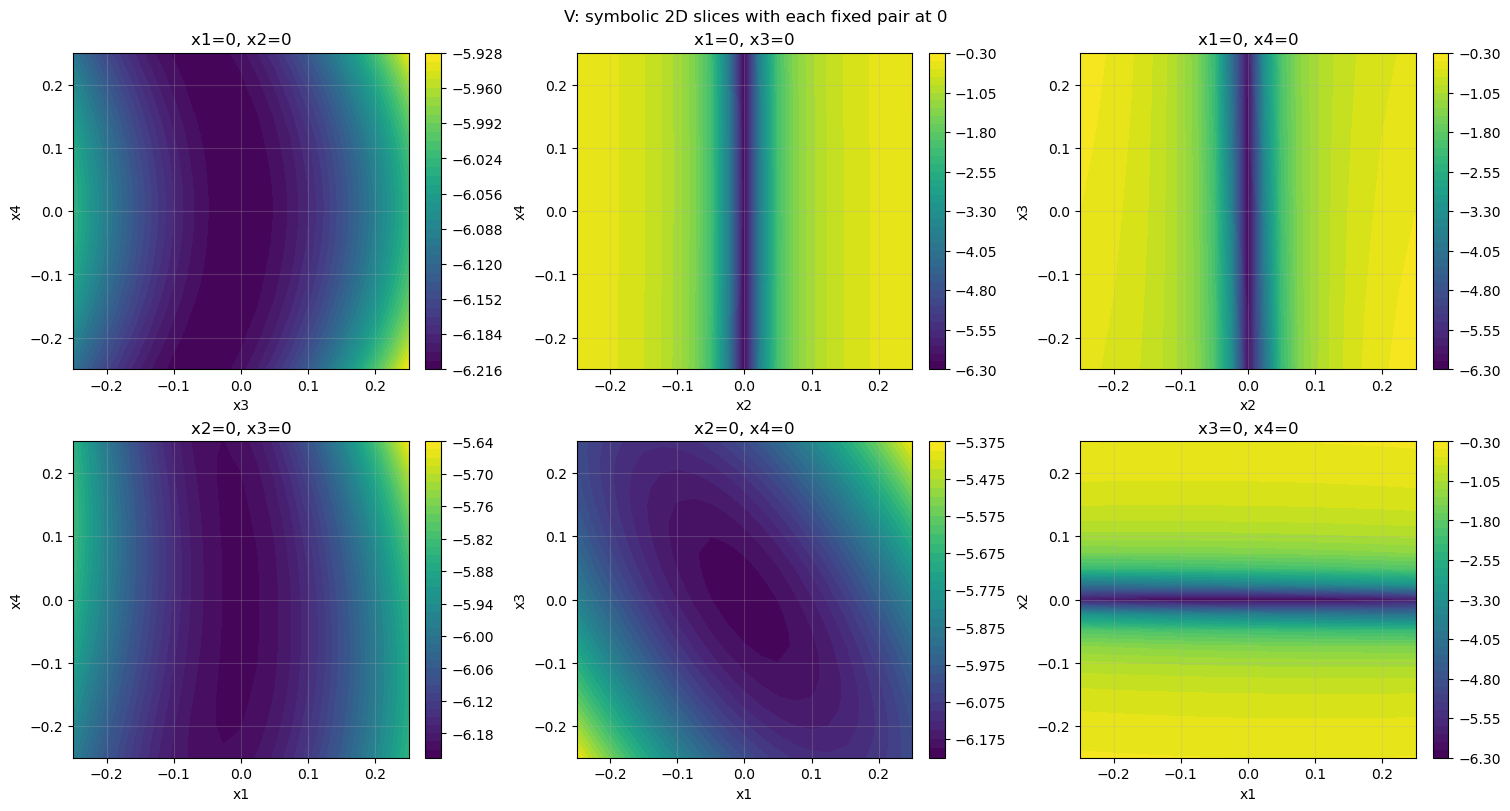

### Vdot

**Original\ Vdot**  

operations: `2334`, expression too large for full Math rendering

```text
x2*(-0.79474337497756261*x1*(-0.3143580049734382*x3*(x2 + 7.372296470101777*exp(x4) + sin(x1))*sin(x2) - 7.820626741626682/((x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))**2 + 1)**0.5)/(x1**2 + 1)**1.5 - 1.0*x3*(-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)*exp(x4)*sin(x4)*cos(x1)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**1.5 + 0.79474337497756261*(-0.3143580049734382*x3*sin(x2)*cos(x1) + 3.910313370813341*(2*sin(x4)*cos(x1) + 2)*(x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))/((x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))**2 + 1)**1.5)/(x1**2 + 1)**0.5) + x4*(0.79474337497756261*(-7.820626741626682*(-1.0*x1 - 1.0*x3 - 1.0*(x2 + x4 + sin(x1))*sin(x4) - 55.50221287045514*sin(x2))/((x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))**2 + 1)**1.5 - 0.3143580049734382*(x2 + 7.37229647010 ... [truncated]
```

############

...

operations: `491`, expression too large for full Math rendering

```text
(-31789.734999102504*(-0.3143580049734382*x3*(sin(x1) + 7.372296470101777) + 434.0620901941381*(x1 + x3)/((x1 + x3)**2 + 1)**1.5)/((24 - 4*cos(x3)**2)*(x1**2 + 1)**0.5) - 20000.0*(-x3/((25.08818286347214 - sin(x1))**2 + 1)**0.5 + 6.2153912910801678*(x1 + x3)*sin(x1)/((x1**2 + 1)**0.5*((x1 + x3)**2 + 1)**1.5))*cos(x3)/(24 - 4*cos(x3)**2))*(3.1789734999102504*(-0.3143580049734382*x3*(sin(x1) + 7.372296470101777) + 434.0620901941381*(x1 + x3)/((x1 + x3)**2 + 1)**1.5)/((24 - 4*cos(x3)**2)*(x1**2 + 1)**0.5) + 2*(-x3/((25.08818286347214 - sin(x1))**2 + 1)**0.5 + 6.2153912910801678*(x1 + x3)*sin(x1)/((x1**2 + 1)**0.5*((x1 + x3)**2 + 1)**1.5))*cos(x3)/(24 - 4*cos(x3)**2))*(sqrt((x1**2 + x3**2)*(3.1789734999102504*(-0.3143580049734382*x3*(sin(x1) + 7.372296470101777) + 434.0620901941381*(x1 + x3)/((x1 + x3)**2 + 1)**1.5)/((24 - 4*cos(x3)**2)*(x1**2 + 1)**0.5) + 2*(-x3/((25.08818286347214 - sin(x1 ... [truncated]
```

**Vdot_{x3=0,x4=0}(x1,x2)**  

operations: `455`, expression too large for full Math rendering

```text
-0.31076956455400839*x2*(x1 + 55.50221287045514*sin(x2))*(2*x2 + 2*sin(x1))/((x1**2 + 1)**0.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**1.5) - 68.9935941021409*x2*(x1 + 55.50221287045514*sin(x2))*cos(x2)/((x1**2 + 1)**0.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**1.5) + x2*(6.2153912910801678*x1/((x1**2 + 1)**1.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**0.5) + 6.2153912910801678*(x1 + 55.50221287045514*sin(x2))/((x1**2 + 1)**0.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**1.5)) + (-3107.6956455400839*(x1 + 55.50221287045514*sin(x2))*(2*x2 + 2*sin(x1))/((x1**2 + 1)**0.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**1.5) - 689935.941021409*(x1 + 55.50221287045514*sin(x2))*cos(x2)/((x1**2 + 1)**0.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**1.5))*(0.31076956455400839*(x1 + 55.50221287045514*sin(x2))*(2*x2 + 2*sin(x1))/((x1**2 + 1)**0.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**1.5) + 68.99 ... [truncated]
```

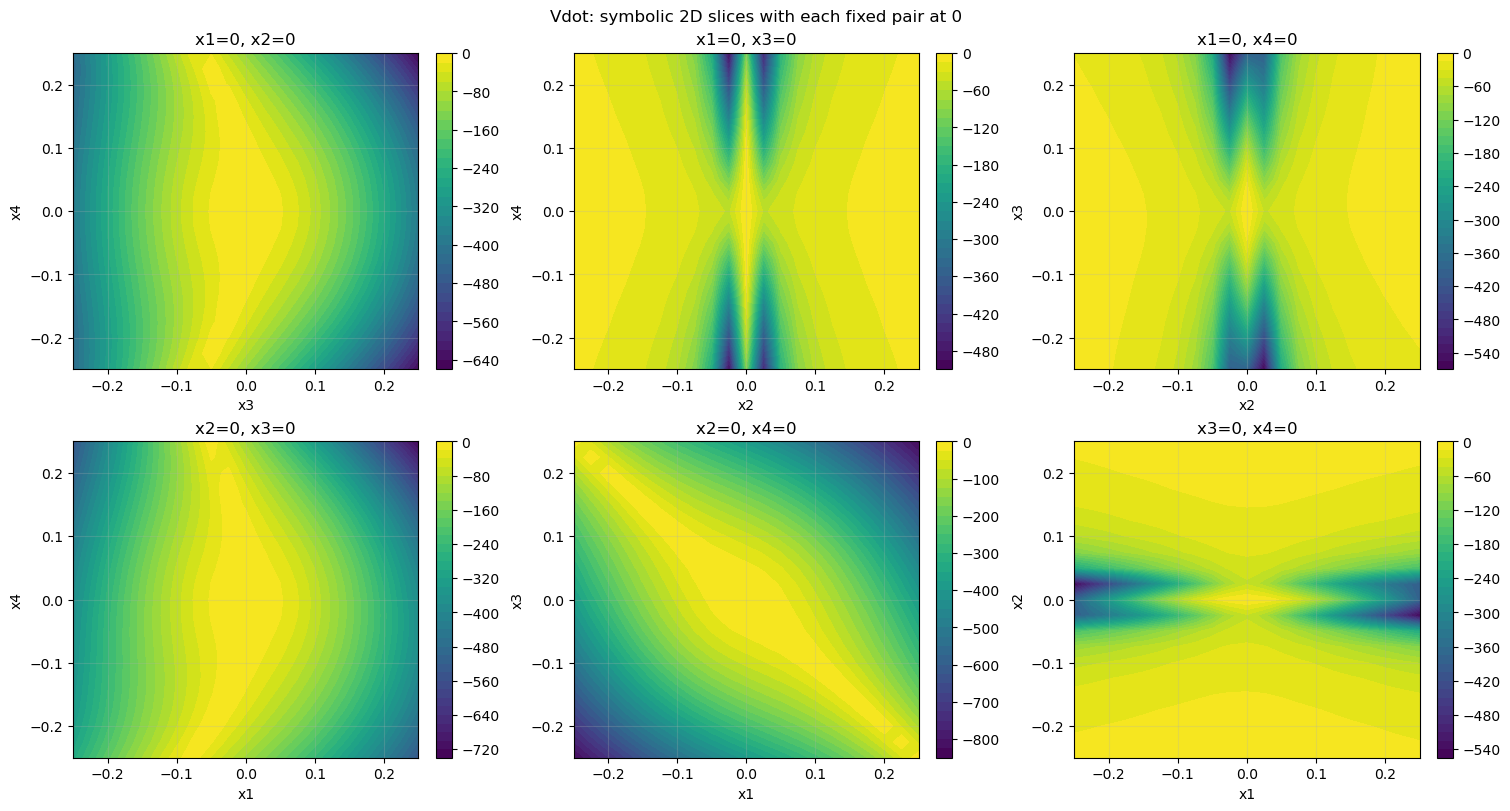

### b_norm_sq

**Original\ b_norm_sq**  

operations: `393`, expression too large for full Math rendering

```text
(4*(0.5*x3*(2*cos(x2) - 2)*(-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**1.5 + 0.79474337497756261*(-0.3143580049734382*x3*(x2 + 7.372296470101777*exp(x4) + sin(x1))*cos(x2) - 0.3143580049734382*x3*sin(x2) + 3.910313370813341*(2*sin(x4) + 111.0044257409103*cos(x2))*(x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))/((x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))**2 + 1)**1.5)/(x1**2 + 1)**0.5)/(24 - 4*cos(x3)**2) + 2*(-x3*(2.0*x2 - 4.0*x4 + 2.0*sin(x1) - 2.0*sin(x2) - 50.17636572694428)*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**1.5 - x3*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**0.5 - x3*exp(x4)*cos(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**0.5 + 0.79474337497756261*(-2 ... [truncated]
```

############

...

```text
(0.31076956455400839*(x1 + (x4 + sin(x1))*sin(x4))*(2*(x4 + sin(x1))*cos(x4) + 2*sin(x4))/((x1**2 + 1)**0.5*((x1 + (x4 + sin(x1))*sin(x4))**2 + 1)**1.5) + 0.62153912910801678*(x1 + (x4 + sin(x1))*sin(x4))*(2*sin(x4) + 111.0044257409103)/((x1**2 + 1)**0.5*((x1 + (x4 + sin(x1))*sin(x4))**2 + 1)**1.5))*(3107.6956455400839*(x1 + (x4 + sin(x1))*sin(x4))*(2*(x4 + sin(x1))*cos(x4) + 2*sin(x4))/((x1**2 + 1)**0.5*((x1 + (x4 + sin(x1))*sin(x4))**2 + 1)**1.5) + 6215.3912910801678*(x1 + (x4 + sin(x1))*sin(x4))*(2*sin(x4) + 111.0044257409103)/((x1**2 + 1)**0.5*((x1 + (x4 + sin(x1))*sin(x4))**2 + 1)**1.5))
```

**b_norm_sq_{x2=0,x4=0}(x1,x3)**  

operations: `103`, expression too large for full Math rendering

```text
(3.1789734999102504*(-0.3143580049734382*x3*(sin(x1) + 7.372296470101777) + 434.0620901941381*(x1 + x3)/((x1 + x3)**2 + 1)**1.5)/((24 - 4*cos(x3)**2)*(x1**2 + 1)**0.5) + 2*(-x3/((25.08818286347214 - sin(x1))**2 + 1)**0.5 + 6.2153912910801678*(x1 + x3)*sin(x1)/((x1**2 + 1)**0.5*((x1 + x3)**2 + 1)**1.5))*cos(x3)/(24 - 4*cos(x3)**2))*(31789.734999102504*(-0.3143580049734382*x3*(sin(x1) + 7.372296470101777) + 434.0620901941381*(x1 + x3)/((x1 + x3)**2 + 1)**1.5)/((24 - 4*cos(x3)**2)*(x1**2 + 1)**0.5) + 20000.0*(-x3/((25.08818286347214 - sin(x1))**2 + 1)**0.5 + 6.2153912910801678*(x1 + x3)*sin(x1)/((x1**2 + 1)**0.5*((x1 + x3)**2 + 1)**1.5))*cos(x3)/(24 - 4*cos(x3)**2))
```

<IPython.core.display.Math object>

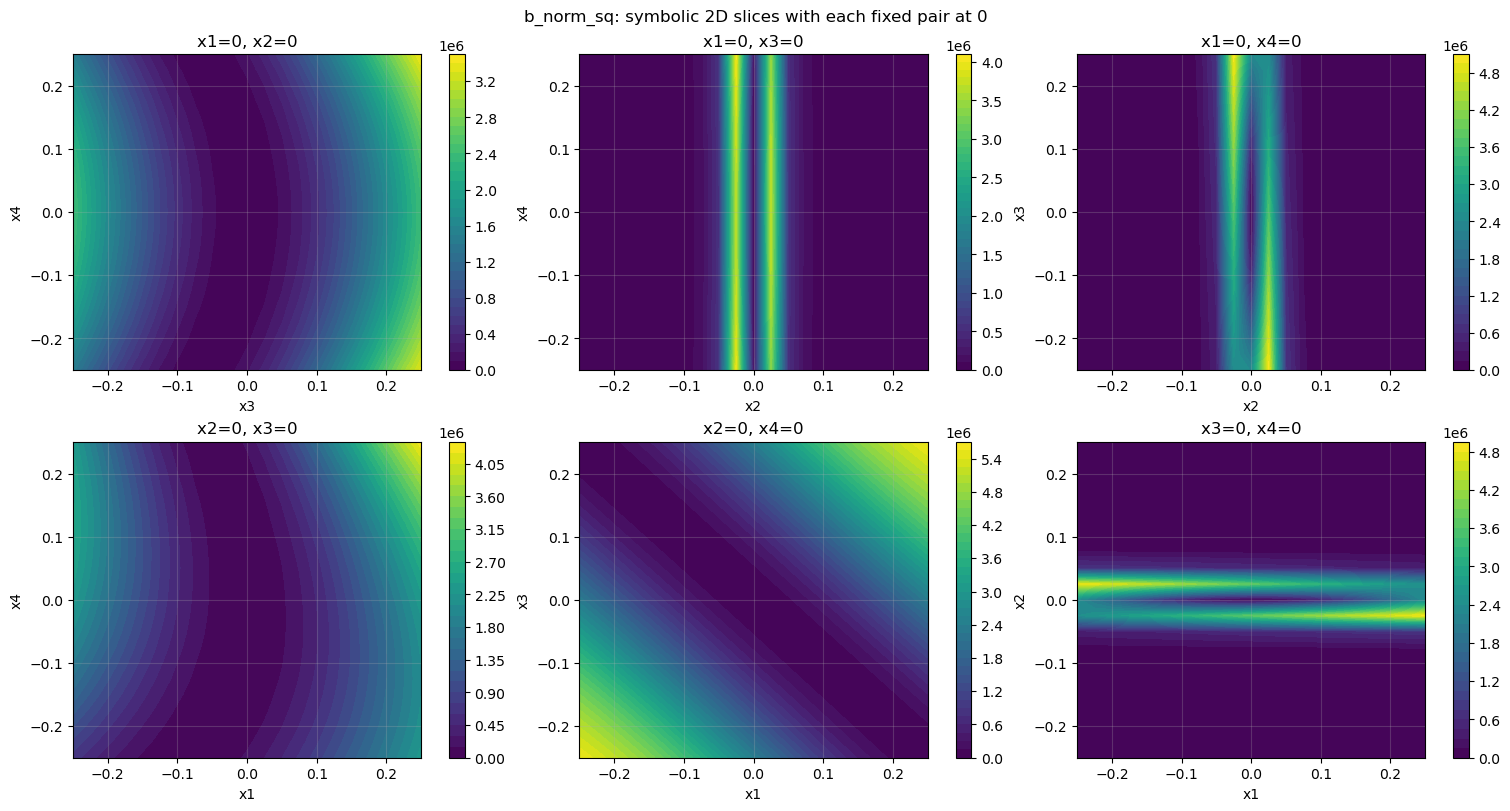

### a

**Original\ a**  

operations: `379`, expression too large for full Math rendering

```text
x2*(-0.79474337497756261*x1*(-0.3143580049734382*x3*(x2 + 7.372296470101777*exp(x4) + sin(x1))*sin(x2) - 7.820626741626682/((x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))**2 + 1)**0.5)/(x1**2 + 1)**1.5 - 1.0*x3*(-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)*exp(x4)*sin(x4)*cos(x1)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**1.5 + 0.79474337497756261*(-0.3143580049734382*x3*sin(x2)*cos(x1) + 3.910313370813341*(2*sin(x4)*cos(x1) + 2)*(x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))/((x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))**2 + 1)**1.5)/(x1**2 + 1)**0.5) + x4*(0.79474337497756261*(-7.820626741626682*(-1.0*x1 - 1.0*x3 - 1.0*(x2 + x4 + sin(x1))*sin(x4) - 55.50221287045514*sin(x2))/((x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))**2 + 1)**1.5 - 0.3143580049734382*(x2 + 7.37229647010 ... [truncated]
```

############

...

operations: `89`, expression too large for full Math rendering

```text
x2*(-0.24983394182380371*x3*sin(x2) + 6.2153912910801678*(x3 + 55.50221287045514*sin(x2))/((x3 + 55.50221287045514*sin(x2))**2 + 1)**1.5) + (-4*x2 + 40*sin(x3)*cos(x3))*(-0.24983394182380371*x3*(x2 + 7.372296470101777)*cos(x2) - 0.24983394182380371*x3*sin(x2) + 344.9679705107045*(x3 + 55.50221287045514*sin(x2))*cos(x2)/((x3 + 55.50221287045514*sin(x2))**2 + 1)**1.5)/(24 - 4*cos(x3)**2) + (-2*x2*cos(x3) + 120*sin(x3))*(6.2153912910801678*x2*(x3 + 55.50221287045514*sin(x2))/((x3 + 55.50221287045514*sin(x2))**2 + 1)**1.5 - x3/((-x2 + sin(x2) + 25.08818286347214)**2 + 1)**0.5 - 1.8418498874192408*x3*sin(x2))/(24 - 4*cos(x3)**2)
```

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

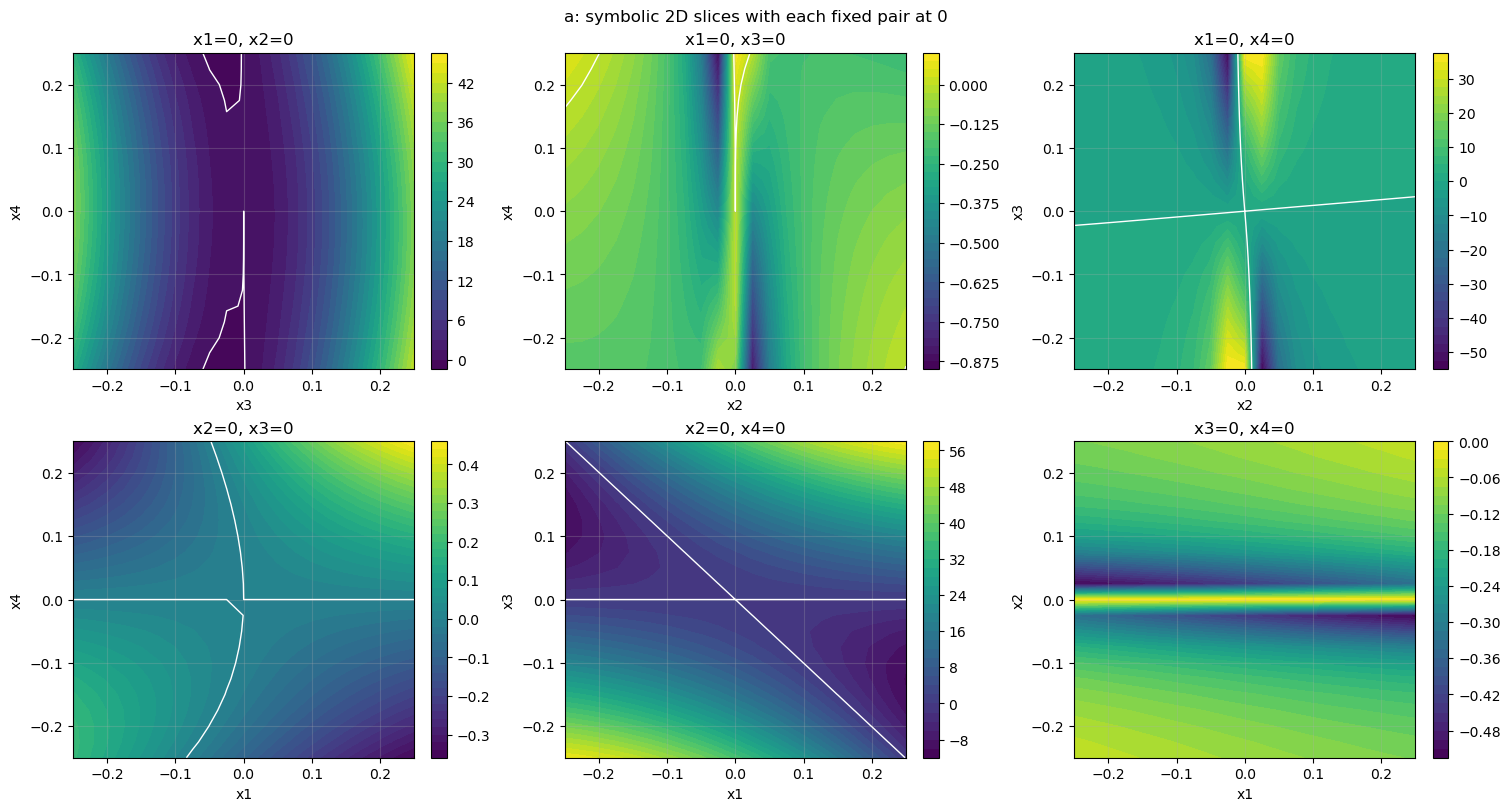

### u

**Original\ u**  

operations: `1757`, expression too large for full Math rendering

```text
(-40000.0*(0.5*x3*(2*cos(x2) - 2)*(-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**1.5 + 0.79474337497756261*(-0.3143580049734382*x3*(x2 + 7.372296470101777*exp(x4) + sin(x1))*cos(x2) - 0.3143580049734382*x3*sin(x2) + 3.910313370813341*(2*sin(x4) + 111.0044257409103*cos(x2))*(x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))/((x1 + x3 + (x2 + x4 + sin(x1))*sin(x4) + 55.50221287045514*sin(x2))**2 + 1)**1.5)/(x1**2 + 1)**0.5)/(24 - 4*cos(x3)**2) - 20000.0*(-x3*(2.0*x2 - 4.0*x4 + 2.0*sin(x1) - 2.0*sin(x2) - 50.17636572694428)*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**1.5 - x3*exp(x4)*sin(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**0.5 - x3*exp(x4)*cos(x4)/((-x2 + 2*x4 - sin(x1) + sin(x2) + 25.08818286347214)**2 + 1)**0.5 + 0.79474337 ... [truncated]
```

############

...

operations: `382`, expression too large for full Math rendering

```text
(-31789.734999102504*(-0.3143580049734382*x3*(sin(x1) + 7.372296470101777) + 434.0620901941381*(x1 + x3)/((x1 + x3)**2 + 1)**1.5)/((24 - 4*cos(x3)**2)*(x1**2 + 1)**0.5) - 20000.0*(-x3/((25.08818286347214 - sin(x1))**2 + 1)**0.5 + 6.2153912910801678*(x1 + x3)*sin(x1)/((x1**2 + 1)**0.5*((x1 + x3)**2 + 1)**1.5))*cos(x3)/(24 - 4*cos(x3)**2))*(sqrt((x1**2 + x3**2)*(3.1789734999102504*(-0.3143580049734382*x3*(sin(x1) + 7.372296470101777) + 434.0620901941381*(x1 + x3)/((x1 + x3)**2 + 1)**1.5)/((24 - 4*cos(x3)**2)*(x1**2 + 1)**0.5) + 2*(-x3/((25.08818286347214 - sin(x1))**2 + 1)**0.5 + 6.2153912910801678*(x1 + x3)*sin(x1)/((x1**2 + 1)**0.5*((x1 + x3)**2 + 1)**1.5))*cos(x3)/(24 - 4*cos(x3)**2))*(31789.734999102504*(-0.3143580049734382*x3*(sin(x1) + 7.372296470101777) + 434.0620901941381*(x1 + x3)/((x1 + x3)**2 + 1)**1.5)/((24 - 4*cos(x3)**2)*(x1**2 + 1)**0.5) + 20000.0*(-x3/((25.08818286347214 -  ... [truncated]
```

**u_{x3=0,x4=0}(x1,x2)**  

operations: `345`, expression too large for full Math rendering

```text
(-3107.6956455400839*(x1 + 55.50221287045514*sin(x2))*(2*x2 + 2*sin(x1))/((x1**2 + 1)**0.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**1.5) - 689935.941021409*(x1 + 55.50221287045514*sin(x2))*cos(x2)/((x1**2 + 1)**0.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**1.5))*(-0.31076956455400839*x2*(x1 + 55.50221287045514*sin(x2))*(2*x2 + 2*sin(x1))/((x1**2 + 1)**0.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**1.5) - 68.9935941021409*x2*(x1 + 55.50221287045514*sin(x2))*cos(x2)/((x1**2 + 1)**0.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**1.5) + x2*(6.2153912910801678*x1/((x1**2 + 1)**1.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**0.5) + 6.2153912910801678*(x1 + 55.50221287045514*sin(x2))/((x1**2 + 1)**0.5*((x1 + 55.50221287045514*sin(x2))**2 + 1)**1.5)) + sqrt((x1**2 + x2**2)*(0.31076956455400839*(x1 + 55.50221287045514*sin(x2))*(2*x2 + 2*sin(x1))/((x1**2 + 1)**0.5*((x1 + 55.50221287045514*sin(x2)) ... [truncated]
```

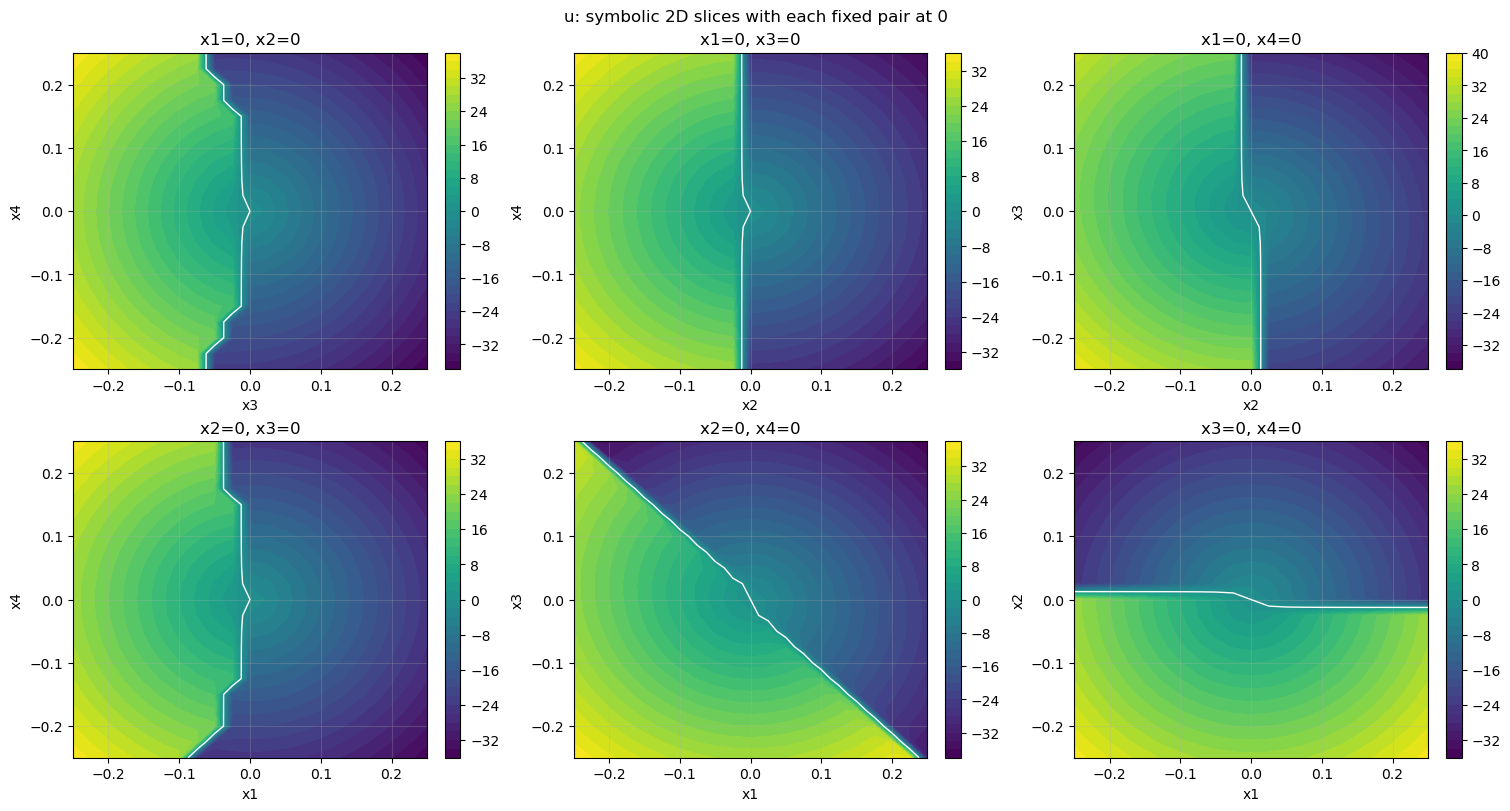

In [94]:
import itertools
import matplotlib.pyplot as plt
from IPython.display import display, Math, Markdown
from sympy import lambdify, latex, count_ops

# Symbolic contour slices for all fixed-pair combinations.
# For each subplot, two states are fixed at 0 and the remaining two are plotted.
state_symbols = [x1, x2, x3, x4]
state_names = ["x1", "x2", "x3", "x4"]
state_ranges = [x1_vals, x2_vals, x3_vals, x4_vals]

# Large expressions such as Vdot/u can freeze the notebook renderer if fully printed as LaTeX.
MAX_LATEX_CHARS = 1200
MAX_TEXT_CHARS = 900
SHOW_SLICE_EXPRESSIONS = True

symbolic_quantities = [
    ("V", V_func),
    ("Vdot", V_dot_func),
    ("b_norm_sq", b_norm_squared[0]),
    ("a", a),
    ("u", u_func),
]

quantity_funcs = [
    (name, expr, lambdify(state_symbols, expr, modules="numpy"))
    for name, expr in symbolic_quantities
]

fixed_pair_combinations = list(itertools.combinations(range(4), 2))


def _as_grid_values(func, args, shape):
    values = np.asarray(func(*args), dtype=float)
    if values.ndim == 0:
        values = np.full(shape, float(values))
    return values


def _expr_preview(expr):
    text = str(expr)
    if len(text) > MAX_TEXT_CHARS:
        text = text[:MAX_TEXT_CHARS] + " ... [truncated]"
    return text


def _display_expression(label, expr):
    ops = count_ops(expr)
    latex_expr = None
    try:
        latex_expr = latex(expr)
    except Exception:
        latex_expr = None

    if latex_expr is not None and len(latex_expr) <= MAX_LATEX_CHARS:
        display(Math(rf"{label} = {latex_expr}"))
    else:
        display(Markdown(f"**{label}**  "))
        display(Markdown(f"operations: `{ops}`, expression too large for full Math rendering"))
        display(Markdown(f"```text\n{_expr_preview(expr)}\n```"))


def _display_original_and_slice_functions(quantity_name, quantity_expr):
    display(Markdown(f"### {quantity_name}"))
    _display_expression(f"Original\\ {quantity_name}", quantity_expr)
    display(Markdown("############"))

    if not SHOW_SLICE_EXPRESSIONS:
        return

    display(Markdown("Corresponding slice functions, with each fixed pair set to zero:"))
    for fixed_pair in fixed_pair_combinations:
        free_pair = [i for i in range(4) if i not in fixed_pair]
        fixed_i, fixed_j = fixed_pair
        free_i, free_j = free_pair
        subs = {
            state_symbols[fixed_i]: 0,
            state_symbols[fixed_j]: 0,
        }
        # Do not call simplify here. It can be much slower than the plot itself.
        slice_expr = quantity_expr.subs(subs)
        label = (
            rf"{quantity_name}_{{{state_names[fixed_i]}=0,{state_names[fixed_j]}=0}}"
            rf"({state_names[free_i]},{state_names[free_j]})"
        )
        _display_expression(label, slice_expr)


for quantity_name, quantity_expr, quantity_func in quantity_funcs:
    _display_original_and_slice_functions(quantity_name, quantity_expr)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
    axes = axes.ravel()
    fig.suptitle(f"{quantity_name}: symbolic 2D slices with each fixed pair at 0")

    for ax, fixed_pair in zip(axes, fixed_pair_combinations):
        free_pair = [i for i in range(4) if i not in fixed_pair]
        free_i, free_j = free_pair
        fixed_i, fixed_j = fixed_pair

        grid_i, grid_j = np.meshgrid(
            state_ranges[free_i], state_ranges[free_j], indexing="ij"
        )
        args = [None, None, None, None]
        args[free_i] = grid_i
        args[free_j] = grid_j
        args[fixed_i] = 0.0
        args[fixed_j] = 0.0

        values = _as_grid_values(quantity_func, args, grid_i.shape)
        finite_values = values[np.isfinite(values)]
        if finite_values.size == 0:
            ax.text(0.5, 0.5, "all non-finite", ha="center", va="center")
            ax.set_axis_off()
            continue

        cs = ax.contourf(grid_i, grid_j, values, levels=40, cmap="viridis")
        ax.contour(grid_i, grid_j, values, levels=[0.0], colors="white", linewidths=1.0)
        ax.set_xlabel(state_names[free_i])
        ax.set_ylabel(state_names[free_j])
        ax.set_title(
            f"{state_names[fixed_i]}=0, {state_names[fixed_j]}=0"
        )
        ax.grid(True, alpha=0.25)
        fig.colorbar(cs, ax=ax)

    plt.show()



In [95]:
# # === Certified ROA estimate and plot ===
# # ROA = largest sublevel set {V - V(0) <= c_cert} that
# #   (i)  fits inside the verification box        -> c_box
# #   (ii) contains no bounded-control margin violation
# #        a - U_MAX*|b| + CLF_ALPHA*V <= 0 inside -> c_viol
# # c_cert = min(c_box, c_viol). Shown on two 2D slices, with the LQR
# # reference quadratic's certified ROA for comparison (paper Fig. 1d style).
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# from sympy import lambdify
# import EvaluatePrime
# from SystemDynamics import R as _Rfn

# _r = float(np.asarray(_Rfn(0.0, 0.0, 0.0, 0.0))[1, 1])


# def _certified_level(V_grid, V0, a_grid, b_abs_grid, mesh):
#     V_rel = V_grid - V0
#     c_box = max(EvaluatePrime._boundary_min(V_rel), 0.0)
#     margin = (
#         a_grid
#         - EvaluatePrime.U_MAX * b_abs_grid
#         + EvaluatePrime.CLF_ALPHA * np.maximum(V_rel, 0.0)
#     )
#     r2 = sum(m**2 for m in mesh)
#     viol = (
#         (r2 > EvaluatePrime.ORIGIN_EXCLUDE_RADIUS**2)
#         & (margin > 0)
#         & (V_rel < c_box)
#     )
#     c_viol = float(V_rel[viol].min()) if np.any(viol) else np.inf
#     c_cert = min(c_box, c_viol)
#     frac = float(np.mean(V_rel < c_cert))
#     return V_rel, margin, c_box, c_viol, c_cert, frac


# # --- current expression (grid quantities from the earlier cells) ---
# V0_cur = float(simplified_expr.subs({x1: 0, x2: 0, x3: 0, x4: 0}))
# b_abs_cur = np.sqrt(np.maximum(b_nvals, 0.0) * _r)  # |b|, single active input
# V_rel_cur, margin_cur, c_box_cur, c_viol_cur, c_cert_cur, frac_cur = _certified_level(
#     V_vals, V0_cur, a_vals, b_abs_cur, train_data.mesh
# )

# # --- LQR reference quadratic, same treatment ---
# lqr_expr = (
#     1.821 * x1**2 + 2.318 * x1 * x2 - 12.932 * x1 * x3 - 4.837 * x1 * x4
#     + 1.64 * x2**2 - 18.72 * x2 * x3 - 6.96 * x2 * x4
#     + 56.19 * x3**2 + 40.81 * x3 * x4 + 7.612 * x4**2
# )
# _lqr_f = lambdify((x1, x2, x3, x4), lqr_expr, "numpy")
# V_lqr = np.asarray(_lqr_f(*train_data.mesh), dtype=float)
# _grads = np.gradient(V_lqr, *x_vals, edge_order=2)
# _fvec, _gcol = EvaluatePrime._dynamics_on_grid(train_data, train_data.mesh)
# a_lqr = sum(g * fc for g, fc in zip(_grads, _fvec))
# b_abs_lqr = np.abs(sum(g * gc for g, gc in zip(_grads, _gcol)))
# V_rel_lqr, _, c_box_lqr, c_viol_lqr, c_cert_lqr, frac_lqr = _certified_level(
#     V_lqr, 0.0, a_lqr, b_abs_lqr, train_data.mesh
# )

# print(
#     f"current CLF : c_box={c_box_cur:.5f}  c_viol={c_viol_cur:.5f}  "
#     f"-> c_cert={c_cert_cur:.5f}  (covers {100*frac_cur:.2f}% of box)"
# )
# print(
#     f"LQR ref     : c_box={c_box_lqr:.5f}  c_viol={c_viol_lqr:.5f}  "
#     f"-> c_cert={c_cert_lqr:.5f}  (covers {100*frac_lqr:.2f}% of box)"
# )

# # --- dense slices for smooth level sets ---
# _V_cur_f = lambdify((x1, x2, x3, x4), simplified_expr, "numpy")
# _ss = np.linspace(-0.25, 0.25, 300)
# S1, S2 = np.meshgrid(_ss, _ss, indexing="ij")
# Z0 = np.zeros_like(S1)
# center = GRID_POINTS // 2

# slice_defs = [
#     (r"$x_1$", r"$x_2$", (S1, S2, Z0, Z0), x1_vals, x2_vals,
#      (slice(None), slice(None), center, center), r"slice $x_3=x_4=0$"),
#     (r"$x_3$", r"$x_4$", (Z0, Z0, S1, S2), x3_vals, x4_vals,
#      (center, center, slice(None), slice(None)), r"slice $x_1=x_2=0$"),
# ]

# viol_grid = (margin_cur > 0) & (V_rel_cur < c_box_cur)

# fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
# for ax, (xl, yl, args, gx, gy, idx, title) in zip(axes, slice_defs):
#     Vs = np.asarray(_V_cur_f(*args), dtype=float) - V0_cur
#     Vl = np.asarray(_lqr_f(*args), dtype=float)

#     cs = ax.contourf(S1, S2, Vs, levels=30, cmap="coolwarm", alpha=0.85)
#     fig.colorbar(cs, ax=ax, label=r"$V(x)-V(0)$")

#     if np.isfinite(c_cert_cur) and c_cert_cur > 0:
#         ax.contour(S1, S2, Vs, levels=[c_cert_cur], colors="green", linewidths=2.5)
#     if np.isfinite(c_cert_lqr) and c_cert_lqr > 0:
#         ax.contour(S1, S2, Vl, levels=[c_cert_lqr], colors="magenta",
#                    linestyles="--", linewidths=2.0)

#     sl = viol_grid[idx]
#     if np.any(sl):
#         ax.contourf(gx, gy, sl.T.astype(float), levels=[0.5, 1.5],
#                     colors="red", alpha=0.35)

#     ax.set_xlabel(xl)
#     ax.set_ylabel(yl)
#     ax.set_title(title)
#     ax.grid(alpha=0.25)

# fig.legend(
#     handles=[
#         Line2D([], [], color="green", lw=2.5,
#                label=f"certified ROA, current CLF (c={c_cert_cur:.4g})"),
#         Line2D([], [], color="magenta", ls="--", lw=2,
#                label=f"certified ROA, LQR ref (c={c_cert_lqr:.4g})"),
#         Line2D([], [], color="red", lw=6, alpha=0.35,
#                label="bounded-margin violations (current CLF)"),
#     ],
#     loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08),
# )
# fig.suptitle(
#     "Certified ROA: largest sublevel set inside the box "
#     "with no bounded-control margin violation"
# )
# plt.show()


In [96]:
# # === Certified ROA estimate and plot ===
# # ROA = largest sublevel set {V - V(0) <= c_cert} that
# #   (i)  fits inside the verification box        -> c_box
# #   (ii) contains no bounded-control margin violation
# #        a - U_MAX*|b| + CLF_ALPHA*V <= 0 inside -> c_viol
# # c_cert = min(c_box, c_viol). Shown on two 2D slices, with the LQR
# # reference quadratic's certified ROA for comparison (paper Fig. 1d style).
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# from sympy import lambdify
# import EvaluatePrime
# from SystemDynamics import R as _Rfn

# _r = float(np.asarray(_Rfn(0.0, 0.0, 0.0, 0.0))[1, 1])


# def _certified_level(V_grid, V0, a_grid, b_abs_grid, mesh):
#     V_rel = V_grid - V0
#     c_box = max(EvaluatePrime._boundary_min(V_rel), 0.0)
#     margin = (
#         a_grid
#         - EvaluatePrime.U_MAX * b_abs_grid
#         + EvaluatePrime.CLF_ALPHA * np.maximum(V_rel, 0.0)
#     )
#     r2 = sum(m**2 for m in mesh)
#     viol = (
#         (r2 > EvaluatePrime.ORIGIN_EXCLUDE_RADIUS**2)
#         & (margin > 0)
#         & (V_rel < c_box)
#     )
#     c_viol = float(V_rel[viol].min()) if np.any(viol) else np.inf
#     c_cert = min(c_box, c_viol)
#     frac = float(np.mean(V_rel < c_cert))
#     return V_rel, margin, c_box, c_viol, c_cert, frac


# # --- current expression (grid quantities from the earlier cells) ---
# V0_cur = float(simplified_expr.subs({x1: 0, x2: 0, x3: 0, x4: 0}))
# b_abs_cur = np.sqrt(np.maximum(b_nvals, 0.0) * _r)  # |b|, single active input
# V_rel_cur, margin_cur, c_box_cur, c_viol_cur, c_cert_cur, frac_cur = _certified_level(
#     V_vals, V0_cur, a_vals, b_abs_cur, train_data.mesh
# )

# # --- LQR reference quadratic, same treatment ---
# lqr_expr = (
#     1.821 * x1**2 + 2.318 * x1 * x2 - 12.932 * x1 * x3 - 4.837 * x1 * x4
#     + 1.64 * x2**2 - 18.72 * x2 * x3 - 6.96 * x2 * x4
#     + 56.19 * x3**2 + 40.81 * x3 * x4 + 7.612 * x4**2
# )
# _lqr_f = lambdify((x1, x2, x3, x4), lqr_expr, "numpy")
# V_lqr = np.asarray(_lqr_f(*train_data.mesh), dtype=float)
# _grads = np.gradient(V_lqr, *x_vals, edge_order=2)
# _fvec, _gcol = EvaluatePrime._dynamics_on_grid(train_data, train_data.mesh)
# a_lqr = sum(g * fc for g, fc in zip(_grads, _fvec))
# b_abs_lqr = np.abs(sum(g * gc for g, gc in zip(_grads, _gcol)))
# V_rel_lqr, _, c_box_lqr, c_viol_lqr, c_cert_lqr, frac_lqr = _certified_level(
#     V_lqr, 0.0, a_lqr, b_abs_lqr, train_data.mesh
# )

# print(
#     f"current CLF : c_box={c_box_cur:.5f}  c_viol={c_viol_cur:.5f}  "
#     f"-> c_cert={c_cert_cur:.5f}  (covers {100*frac_cur:.2f}% of box)"
# )
# print(
#     f"LQR ref     : c_box={c_box_lqr:.5f}  c_viol={c_viol_lqr:.5f}  "
#     f"-> c_cert={c_cert_lqr:.5f}  (covers {100*frac_lqr:.2f}% of box)"
# )

# # --- dense slices for smooth level sets ---
# _V_cur_f = lambdify((x1, x2, x3, x4), simplified_expr, "numpy")
# _ss = np.linspace(-0.25, 0.25, 300)
# S1, S2 = np.meshgrid(_ss, _ss, indexing="ij")
# Z0 = np.zeros_like(S1)
# center = GRID_POINTS // 2

# slice_defs = [
#     (r"$x_1$", r"$x_2$", (S1, S2, Z0, Z0), x1_vals, x2_vals,
#      (slice(None), slice(None), center, center), r"slice $x_3=x_4=0$"),
#     (r"$x_3$", r"$x_4$", (Z0, Z0, S1, S2), x3_vals, x4_vals,
#      (center, center, slice(None), slice(None)), r"slice $x_1=x_2=0$"),
# ]

# viol_grid = (margin_cur > 0) & (V_rel_cur < c_box_cur)

# fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
# for ax, (xl, yl, args, gx, gy, idx, title) in zip(axes, slice_defs):
#     Vs = np.asarray(_V_cur_f(*args), dtype=float) - V0_cur
#     Vl = np.asarray(_lqr_f(*args), dtype=float)

#     cs = ax.contourf(S1, S2, Vs, levels=30, cmap="coolwarm", alpha=0.85)
#     fig.colorbar(cs, ax=ax, label=r"$V(x)-V(0)$")

#     if np.isfinite(c_cert_cur) and c_cert_cur > 0:
#         ax.contour(S1, S2, Vs, levels=[c_cert_cur], colors="green", linewidths=2.5)
#     if np.isfinite(c_cert_lqr) and c_cert_lqr > 0:
#         ax.contour(S1, S2, Vl, levels=[c_cert_lqr], colors="magenta",
#                    linestyles="--", linewidths=2.0)

#     sl = viol_grid[idx]
#     if np.any(sl):
#         ax.contourf(gx, gy, sl.T.astype(float), levels=[0.5, 1.5],
#                     colors="red", alpha=0.35)

#     ax.set_xlabel(xl)
#     ax.set_ylabel(yl)
#     ax.set_title(title)
#     ax.grid(alpha=0.25)

# fig.legend(
#     handles=[
#         Line2D([], [], color="green", lw=2.5,
#                label=f"certified ROA, current CLF (c={c_cert_cur:.4g})"),
#         Line2D([], [], color="magenta", ls="--", lw=2,
#                label=f"certified ROA, LQR ref (c={c_cert_lqr:.4g})"),
#         Line2D([], [], color="red", lw=6, alpha=0.35,
#                label="bounded-margin violations (current CLF)"),
#     ],
#     loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08),
# )
# fig.suptitle(
#     "Certified ROA: largest sublevel set inside the box "
#     "with no bounded-control margin violation"
# )
# plt.show()


# CLF Verification under Unbounded Control: The Correct Condition

## 1. The condition is an implication on the b = 0 manifold

The manuscript (Eq. 2, Eq. 4) defines a CLF by

$$\inf_u L_{f_u} V(x) < 0 \quad \forall x \neq 0,$$

with $a(x) = \nabla V(x)^T f(x)$ and $b(x) = G(x)^T \nabla V(x)$. Since $u$ is unbounded,
the infimum is $-\infty$ wherever $b(x) \neq 0$, so the entire content of the condition is:

$$b(x) = 0 \;\Longrightarrow\; a(x) < 0 \qquad \forall x \neq 0.$$

This equivalence is stated verbatim in **Liu et al. (2025), Eq. (4)** — manuscript reference [16]:

> "The CLF condition (2) can be equivalently stated as $b(x) = 0 \Rightarrow a(x) < 0$
> for all $x \in \mathcal{D}\setminus\{0\}$, because when $b(x) \neq 0$, (2) can be easily satisfied."

and in **Tan & Packard (2004), Sec. 3.1, Eqs. (3)–(4)**:

> "the crucial place to check is the set of $x$ such that $\frac{\partial V}{\partial x} g(x) = 0$.
> There, the inequality $\frac{\partial V}{\partial x} f(x) < 0$ must be satisfied."

The equivalence originates with **Artstein (1983)** and **Sontag (1989)**.

## 2. Why checking V̇ under Sontag's feedback is vacuous

Under Sontag's formula, wherever $b(x) \neq 0$,

$$\dot V = a - \left(a + \sqrt{a^2 + \|b\|^4}\right) = -\sqrt{a^2 + \|b\|^4} < 0
\quad \text{for } \textbf{any } V.$$

This computation is **Liu et al. (2025), Eq. (5)**, explicitly. Consequence: sampling
$\dot V$ at points where $b \neq 0$ (i.e., almost every grid/random point) can never
falsify a candidate. Only the manifold implication carries information.

## 3. The manifold sampling problem

Section 4.4 of the manuscript (Reversed Van der Pol) identifies the practical issue:

> "uniformly distributed points in $\mathcal{D}$ do not accurately sample the manifold
> $\{x : b(x) = 0\}$"

and the current workaround — keep samples with $\|b(x)\| < 10^{-6}$, check
$a(x) < 10^{-5}$ on them — introduces a hard threshold: the check fires only for
points that land within the tolerance band, and its outcome is discontinuous in
the candidate's coefficients, which is poor feedback for GP. SMT solvers (dReal, Z3)
verify the implication exactly, but as Section 4.4 argues, they are impractical
*inside* the SR loop (binary output, no counterexample transfer, prohibitive cost
per generation). Liu et al. (2025) use SMT precisely because they verify **one**
final candidate, not thousands per generation.

## 4. Robust surrogate: fixed-multiplier S-procedure

Tan & Packard verify the manifold implication via the Positivstellensatz with a
**free polynomial multiplier** $p_2$ on $b$ (their Eq. (12), multi-input Eq. (19)):

$$-\left\{ s_1\left[a(x) - \gamma\right] + p_2(x)\, b(x) + l_2(x) \right\} \in \Sigma_n .$$

Choosing the fixed multiplier $p_2 = -\rho\, b$ and $s_1 = 1$ yields the smooth scalar
condition

$$a(x) - \rho\, \|b(x)\|^2 < -\gamma\, \|x\|^2 \quad \text{for all } x,$$

i.e., an S-procedure with constant multiplier $\rho > 0$. Properties:

- At $b = 0$ it reduces exactly to the manifold condition $a(x) < 0$.
- It is smooth in $x$ and in the candidate's coefficients — no threshold, no
  manifold sampling, usable as a scalar penalty in the GP fitness.
- It is **sufficient** for the CLF condition; for fixed $\rho$ it is conservative
  (Tan & Packard recover non-conservatism by searching over $p_2$; $\rho$ is the
  scalar knob that trades conservatism for cost).

## 5. Sublevel-set restriction (local CLF)

When the condition cannot hold on the whole box, restrict it to a sublevel set —
**Liu et al. (2025), Eq. (23)**:

$$\nabla V \cdot g = 0 \;\wedge\; x \neq 0 \;\wedge\; V(x) \leq c
\;\Longrightarrow\; \nabla V \cdot f < 0,$$

with bisection for the **largest verifiable** $c$ (their Algorithm 2). Tan & Packard's
Sec. 4 (Eqs. (23)–(32)) does the same for SOS, maximizing the certified region.
This is the published basis for the $c^*$ sublevel-set restriction in the framework.

## 6. Origin handling

Numerical/δ-complete verification near the origin is intrinsically unreliable —
**Liu et al. (2025), Remark 2**: counterexamples near the origin are inevitable for
δ-complete solvers. Their remedy: certify an inner neighborhood with a verified
quadratic (Riccati) CLF and check the candidate only on the annulus
$c_1 \leq V(x) \leq c_2$ (their Eqs. (24)–(25)). The manuscript already adopts the
simpler exclusion of a $10^{-3}$ ball, citing [16].

## 7. Implementation

**Grid check:**
```python
a_vals    = grad_V @ f_vals            # a(x) on the mesh
b_abs     = |g_vals^T grad_V|           # scalar active-input channel
margin    = a_vals - rho * b_abs + gamma1
violations = count(margin > 0, outside origin ball, inside {V <= c*})
```

**Falsifier (DE/SHGO) objective — maximize the margin:**
```python
def objective(x):
    a = grad_V(x) @ f(x)
    b = g(x)^T grad_V(x)
    return -(a - rho * abs(b) + gamma1)   # minimize negative margin
```

## References

All verified against the PDFs in `SR_CLF-20260610T092424Z-3-001/SR_CLF/`.

1. **Liu, J., Fitzsimmons, M., Zhou, R., & Meng, Y. (2025).** "Formally verified
   physics-informed neural control Lyapunov functions." *2025 American Control
   Conference (ACC)*. (arXiv:2409.20528)
   — Eq. (4): the condition as $b=0 \Rightarrow a<0$; Eq. (5): Sontag's $\dot V$ is
   negative for any $V$ when $b \neq 0$; Eq. (23) + Algorithm 2: largest verified
   sublevel set; Remark 2: origin handling. *Manuscript reference [16].*

2. **Tan, W., & Packard, A. (2004).** "Searching for control Lyapunov functions
   using sums of squares programming." *Allerton Conference on Communication,
   Control, and Computing*.
   — Sec. 3.1, Eqs. (3)–(4): the manifold condition is the only thing to check;
   Eqs. (12), (19): Positivstellensatz multiplier on $b$, of which the
   $\rho\|b\|^2$ margin is the fixed-multiplier special case; Sec. 4: local CLF
   on a level set.

3. **Artstein, Z. (1983).** "Stabilization with relaxed controls." *Nonlinear
   Analysis: Theory, Methods & Applications*, 7(11), 1163–1173.
   — Original equivalence between CLF existence and stabilizability.
   *Manuscript reference [1].*

4. **Sontag, E. D. (1989).** "A 'universal' construction of Artstein's theorem on
   nonlinear stabilization." *Systems & Control Letters*, 13(2), 117–123.
   — Constructive feedback from a CLF; the formula whose $\dot V$ is negative by
   construction wherever $b \neq 0$. *Manuscript reference [22].*

5. **Freeman, R. A., & Primbs, J. A. (1996).** "Control Lyapunov functions: new
   ideas from an old source." *Proc. 35th IEEE CDC*, 3926–3931.
   — Inverse optimality: the design parameter $\sigma(x)$ specifies the desired
   negativity of $\dot V$, with $L_f V \leq -\sigma$ required wherever $L_g V = 0$
   (their Eq. (4)). Relevant context, **not** the source of the equivalence
   theorem. *Manuscript reference [6].*

---

## Summary

- **The condition:** $b(x) = 0 \Rightarrow a(x) < 0$ on $\{V \leq c^*\} \setminus \{0\}$
  — Liu et al. (2025) Eq. (4); Tan & Packard Sec. 3.1; Artstein (1983), Sontag (1989).
- **Why not $\dot V$:** under Sontag's feedback $\dot V = -\sqrt{a^2 + \|b\|^4} < 0$
  for any $V$ wherever $b \neq 0$ — Liu et al. (2025) Eq. (5). The check is vacuous
  off the manifold.
- **The implemented bounded-input check:** $a - \rho|b| + \gamma_1 < 0$ outside
  the origin ball. For scalar $|u|\leq\rho$, this is the exact pointwise
  control-authority condition and reduces to the strict Artstein check on $b=0$.
- **Scope:** restrict to the largest certified sublevel set (Liu et al. Eq. (23),
  Alg. 2) and handle the origin separately (Liu et al. Remark 2).
